# Finale Grafiken Reproduktion (Standalone)

Dieses Notebook ist **eigenständig** und referenziert keine Ausführung anderer Notebooks.
Alle relevanten Schritte wurden aus den Referenz-Notebooks in dieses Notebook übernommen.

## Ziel
- Alle finalen Auswertungen in einem Lauf erzeugen
- Finale 18 PNGs nach `analysis/output` schreiben
- `manifest_final.csv` und `README.md` automatisch aktualisieren


## Block A: Hauptanalysen (aus MAIN Notebook Best Practice)


# Final Figures V2 – Tier 1 Proof of Concept

Dieses Notebook implementiert die **modernisierten Design-Standards** für Tier 1 Grafiken.

## Design-Standards (Global):
- **Gruppe A**: Blau (`#4C9BE8`), solid, keine Schraffur
- **Gruppe B**: Rot (`#E84C4C`), gestrichelt (`hatch='///'`)
- **Durchschnittszahlen**: Schwarz mit weißem Hintergrund, Versatz für bessere Lesbarkeit
- **Whiskers**: IQR-basiert für Boxplots (1.5×IQR)
- **Error Bars**: ±1 SEM für Barplots

## Tier 1 Grafiken (Proof of Concept):
1. **Grafik 2**: `boxplot_bmi_python_errors.png` – Python-Fehler A vs. B
2. **Grafik 3**: `boxplot_bmi_time_minutes.png` – Bearbeitungszeit A vs. B

Neuer Output-Ordner: `analysis/output/final_v2/`

In [61]:
# Setup und Imports
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Matplotlib Backend und Style
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

# === GLOBALE DESIGN-STANDARDS ===
# Farben: Gruppe A = Blau, Gruppe B = Rot
GROUP_COLORS = {
    'A': '#4C9BE8',  # Blau (solid)
    'B': '#E84C4C',  # Rot (dashed/hatched)
}

GROUP_LABELS = {
    'A': 'Gruppe A (Kontrolle)',
    'B': 'Gruppe B (KI)',
}

# Hatching für Gruppe B (gestrichelt in Barplots)
GROUP_HATCH = {
    'A': '',       # Keine Schraffur
    'B': '///',    # Gestrichelt
}

# Linestyle für Line-Plots
GROUP_LINESTYLE = {
    'A': '-',      # Solid
    'B': '--',     # Dashed
}

print("✅ Design-Standards geladen:")
print(f"  Gruppe A: {GROUP_COLORS['A']} (Blau, solid)")
print(f"  Gruppe B: {GROUP_COLORS['B']} (Rot, dashed)")

✅ Design-Standards geladen:
  Gruppe A: #4C9BE8 (Blau, solid)
  Gruppe B: #E84C4C (Rot, dashed)


In [ ]:
# Pfad-Setup (robust gegen unterschiedliche CWDs)
BASE = Path.cwd()
candidates = [BASE, BASE.parent, BASE.parent.parent, BASE.parent.parent.parent]
PROJECT_ROOT = None
for c in candidates:
    if (c / 'analysis' / 'exports_anonymized').exists():
        PROJECT_ROOT = c
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(f'Konnte analysis/exports_anonymized nicht finden. Start-CWD: {BASE}')

EXPORT_DIR = PROJECT_ROOT / 'analysis' / 'exports_anonymized'
OUTPUT_DIR = PROJECT_ROOT / 'analysis' / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def newest_file(pattern: str):
    """Findet die neueste Datei im EXPORT_DIR mit gegebenem Pattern."""
    files = sorted(EXPORT_DIR.glob(pattern))
    return files[-1] if files else None

# Daten laden (filtered = num_runs_code > 2)
participants_path = newest_file('study_participants-filtered-*.csv') or newest_file('study_participants-*.csv')
task_path = newest_file('study_task_level-filtered-*.csv') or newest_file('study_task_level-*.csv')

if participants_path is None or task_path is None:
    raise FileNotFoundError(f'CSV fehlt in {EXPORT_DIR}.')

participants = pd.read_csv(participants_path)
task_level = pd.read_csv(task_path)

print(f"✅ Daten geladen:")
print(f"  Participants: {participants_path.name}")
print(f"  Task Level: {task_path.name}")
print(f"  Output-Ordner: {OUTPUT_DIR}")
print(f"\nStichprobe: {len(participants)} Teilnehmende")
print(f"  Gruppe A: {(participants['group'] == 'A').sum()}")
print(f"  Gruppe B: {(participants['group'] == 'B').sum()}")

✅ Daten geladen:
  Participants: study_participants-filtered-2026-03-03.csv
  Task Level: study_task_level-filtered-2026-03-03.csv
  Output-Ordner: /home/shaco/bachelor/python-bootcamp-4c-id/analysis/output

Stichprobe: 18 Teilnehmende
  Gruppe A: 9
  Gruppe B: 9


In [63]:
# Daten bereinigen: Admin-User entfernen, nur ernsthafte Teilnahme
if 'participant_id' in participants.columns:
    admin_mask = participants['participant_id'].astype(str).str.strip().str.lower() == 'admin'
    admin_ids = set(participants.loc[admin_mask, 'participant_id'].astype(str))
    participants = participants.loc[~admin_mask].copy()
    if admin_ids and 'participant_id' in task_level.columns:
        task_level = task_level.loc[~task_level['participant_id'].astype(str).isin(admin_ids)].copy()

# Primäranalyse: nur ernsthafte Teilnahme (num_runs_code > 2)
if 'num_runs_code' in participants.columns and 'participant_id' in participants.columns:
    keep_ids = set(participants.loc[participants['num_runs_code'] > 2, 'participant_id'].astype(str))
    participants = participants.loc[participants['participant_id'].astype(str).isin(keep_ids)].copy()
    if 'participant_id' in task_level.columns:
        task_level = task_level.loc[task_level['participant_id'].astype(str).isin(keep_ids)].copy()

# === AFK-FILTERUNG (60-Minuten-Cap pro Step) ===
# Stelle sicher, dass time_on_task_minutes existiert
if 'time_on_task_seconds' in task_level.columns and 'time_on_task_minutes' not in task_level.columns:
    task_level['time_on_task_minutes'] = task_level['time_on_task_seconds'] / 60

# AFK-Regel: Alle Steps > 60 Minuten ausschließen
AFK_CUTOFF_MINUTES = 60
if 'time_on_task_minutes' in task_level.columns:
    rows_before = len(task_level)
    task_level = task_level[task_level['time_on_task_minutes'] <= AFK_CUTOFF_MINUTES].copy()
    rows_removed = rows_before - len(task_level)
    print(f"\n🔴 AFK-Filter angewendet (>{AFK_CUTOFF_MINUTES} Minuten):")
    print(f"  Entfernte Zeilen: {rows_removed}")
    print(f"  Verbleibende Zeilen: {len(task_level)}")

participants['group'] = participants['group'].astype(str)
task_level['group'] = task_level['group'].astype(str)

print(f"✅ Bereinigt:")
print(f"  Finale Stichprobe: {len(participants)} Teilnehmende")
print(f"  Gruppe A: {(participants['group'] == 'A').sum()}")
print(f"  Gruppe B: {(participants['group'] == 'B').sum()}")


🔴 AFK-Filter angewendet (>60 Minuten):
  Entfernte Zeilen: 1
  Verbleibende Zeilen: 221
✅ Bereinigt:
  Finale Stichprobe: 18 Teilnehmende
  Gruppe A: 9
  Gruppe B: 9



📊 Generiere Grafik 2 (Python-Fehler mit M/Mdn-Standard)...


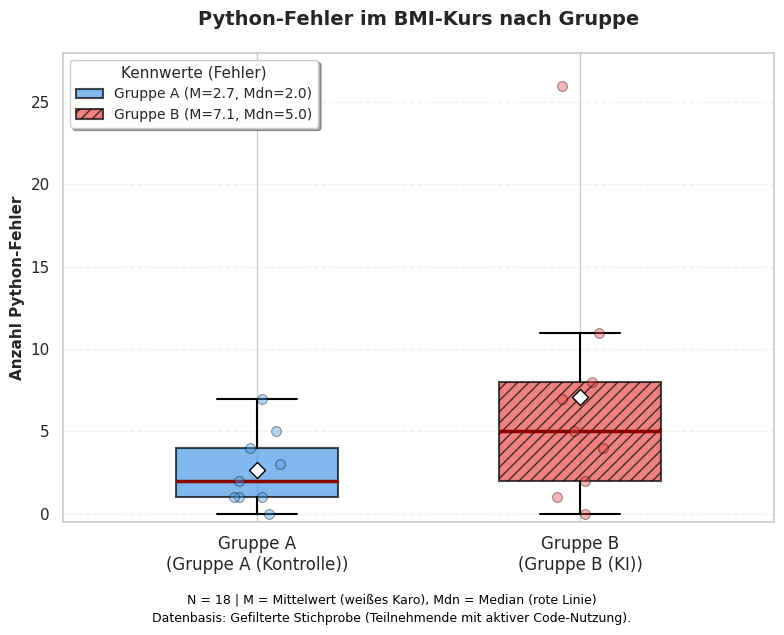

✅ Gespeichert mit Legende oben links: /home/shaco/bachelor/python-bootcamp-4c-id/analysis/output/boxplot_bmi_python_errors.png


In [64]:
# ===== Grafik 2: BMI Python-Fehler (Best-Practice-Edition) =====
print('\n📊 Generiere Grafik 2 (Python-Fehler mit M/Mdn-Standard)...')

fig, ax = plt.subplots(figsize=(8, 6))
legend_handles = []

# Boxplots für beide Gruppen
for i, group in enumerate(['A', 'B']):
    data = participants[participants['group'] == group]['bmi_python_errors'].dropna()
    
    m_val = data.mean()
    mdn_val = data.median()
    
    # Boxplot erstellen mit weißem Diamanten für den Mittelwert
    bp = ax.boxplot(
        [data], positions=[i], widths=0.5, patch_artist=True,
        showmeans=True, # Best Practice: Mittelwert-Symbol aktivieren
        showfliers=False,
        meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='white', markersize=8),
        boxprops=dict(
            facecolor=GROUP_COLORS[group], edgecolor='black', linewidth=1.5, 
            alpha=0.7, hatch=GROUP_HATCH[group]
        ),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5),
        medianprops=dict(color='darkred', linewidth=2.5),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=6, alpha=0.5)
    )
    
    # Kennwerte für die Legende (M und Mdn)
    legend_label = f'Gruppe {group} (M={m_val:.1f}, Mdn={mdn_val:.1f})'
    bp['boxes'][0].set_label(legend_label)
    legend_handles.append(bp['boxes'][0])
    
    # Stripplot overlay (Jitter-Punkte)
    np.random.seed(42)
    jitter = np.random.uniform(-0.08, 0.08, size=len(data))
    ax.scatter(i + jitter, data, color=GROUP_COLORS[group], edgecolors='black', 
               linewidths=0.8, s=50, alpha=0.4, zorder=3)

# Achsen & Design
ax.set_xticks([0, 1])
ax.set_xticklabels([f'Gruppe {g}\n({GROUP_LABELS[g]})' for g in ['A', 'B']], fontsize=12)
ax.set_xlim(-0.6, 1.6)
ax.set_ylabel('Anzahl Python-Fehler', fontsize=11, fontweight='bold')
ax.set_title('Python-Fehler im BMI-Kurs nach Gruppe', fontsize=14, fontweight='bold', pad=20)

# Y-Achse konfigurieren (Puffer für Legende)
ax.set_ylim(-0.5, data.max() + 2 if not data.empty else 25) 
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Legende oben links (wie gewünscht)
ax.legend(
    handles=legend_handles, loc='upper left', fontsize=10, 
    title="Kennwerte (Fehler)", title_fontsize=11, frameon=True, shadow=True
)

# Gestraffte Fußnote (Best Practice)
footer_text = (
    f"N = {len(participants)} | M = Mittelwert (weißes Karo), Mdn = Median (rote Linie)\n"
    "Datenbasis: Gefilterte Stichprobe (Teilnehmende mit aktiver Code-Nutzung)."
)
fig.text(0.5, -0.05, footer_text, ha='center', fontsize=9, color='black', linespacing=1.5)

plt.tight_layout()
out_path = OUTPUT_DIR / 'boxplot_bmi_python_errors.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'✅ Gespeichert mit Legende oben links: {out_path}')


📊 Generiere Grafik 3 (Bearbeitungszeit mit M/Mdn-Standard)...


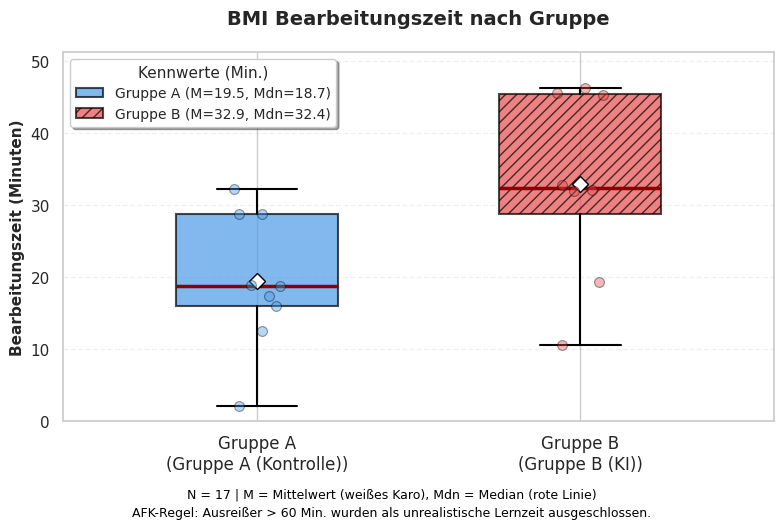

✅ Gespeichert mit Legende unten rechts: /home/shaco/bachelor/python-bootcamp-4c-id/analysis/output/boxplot_bmi_time_minutes.png


In [65]:
# ===== Grafik 3: BMI Bearbeitungszeit (Best-Practice-Edition) =====
print('\n📊 Generiere Grafik 3 (Bearbeitungszeit mit M/Mdn-Standard)...')

fig, ax = plt.subplots(figsize=(8, 5))

# Liste für die Legenden-Objekte
legend_handles = []

# Boxplots für beide Gruppen
for i, group in enumerate(['A', 'B']):
    # Daten laden und AFK-Filter anwenden
    data = participants[participants['group'] == group]['bmi_time_minutes'].dropna()
    data = data[data <= 60]
    
    m_val = data.mean()
    mdn_val = data.median()
    
    # Boxplot erstellen mit weißem Diamanten für den Mittelwert
    bp = ax.boxplot(
        [data], positions=[i], widths=0.5, patch_artist=True,
        showmeans=True, # Best Practice: Mittelwert-Symbol aktivieren
        showfliers=False,
        meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='white', markersize=8),
        boxprops=dict(
            facecolor=GROUP_COLORS[group], edgecolor='black', linewidth=1.5, 
            alpha=0.7, hatch=GROUP_HATCH[group]
        ),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5),
        medianprops=dict(color='darkred', linewidth=2.5),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=6, alpha=0.5)
    )
    
    # Kennwerte für die Legende (M und Mdn)
    legend_label = f'Gruppe {group} (M={m_val:.1f}, Mdn={mdn_val:.1f})'
    bp['boxes'][0].set_label(legend_label)
    legend_handles.append(bp['boxes'][0])
    
    # Stripplot overlay (Jitter-Punkte)
    np.random.seed(42)
    jitter = np.random.uniform(-0.08, 0.08, size=len(data))
    ax.scatter(i + jitter, data, color=GROUP_COLORS[group], edgecolors='black', 
               linewidths=0.8, s=50, alpha=0.4, zorder=3)

# Achsen & Design
ax.set_xticks([0, 1])
ax.set_xticklabels([f'Gruppe {g}\n({GROUP_LABELS[g]})' for g in ['A', 'B']], fontsize=12)
ax.set_xlim(-0.6, 1.6)
ax.set_ylabel('Bearbeitungszeit (Minuten)', fontsize=11, fontweight='bold')
ax.set_title('BMI Bearbeitungszeit nach Gruppe', fontsize=14, fontweight='bold', pad=20)

# Y-Achse konfigurieren (Puffer für Legende)
ax.set_ylim(0, data.max() + 5 if not data.empty else 55) 
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Legende unten rechts (wie gewünscht)
ax.legend(
    handles=legend_handles, loc='upper left', fontsize=10, 
    title="Kennwerte (Min.)", title_fontsize=11, frameon=True, shadow=True
)

# Saubere Fußnote (Best Practice)
footer_text = (
    f"N = {len(participants[participants['bmi_time_minutes'] <= 60])} | "
    "M = Mittelwert (weißes Karo), Mdn = Median (rote Linie)\n"
    "AFK-Regel: Ausreißer > 60 Min. wurden als unrealistische Lernzeit ausgeschlossen."
)
fig.text(0.5, -0.05, footer_text, ha='center', fontsize=9, color='black', linespacing=1.5)

plt.tight_layout()
out_path = OUTPUT_DIR / 'boxplot_bmi_time_minutes.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'✅ Gespeichert mit Legende unten rechts: {out_path}')

In [66]:
# Evaluations-Daten laden (für Fragebogen-Grafiken)
eval_path = newest_file('study_evaluations-*.csv')
if eval_path is None:
    raise FileNotFoundError('Keine study_evaluations CSV gefunden.')

evaluations_raw = pd.read_csv(eval_path)

# Filtern auf ernsthafte Teilnahme (wie bei participants)
if 'participant_id' in evaluations_raw.columns:
    keep_ids_set = set(participants['participant_id'].astype(str))
    evaluations = evaluations_raw[evaluations_raw['participant_id'].astype(str).isin(keep_ids_set)].copy()
else:
    evaluations = evaluations_raw.copy()

evaluations['group'] = evaluations['group'].astype(str)

print(f"✅ Evaluations geladen: {eval_path.name}")
print(f"  Evaluations (gefiltert): {len(evaluations)}")
print(f"  Gruppe A: {(evaluations['group'] == 'A').sum()}")
print(f"  Gruppe B: {(evaluations['group'] == 'B').sum()}")

✅ Evaluations geladen: study_evaluations-unfiltered-2026-03-03.csv
  Evaluations (gefiltert): 16
  Gruppe A: 8
  Gruppe B: 8



📊 Generiere Grafik 7 (NASA-TLX mit korrekten Skalen)...


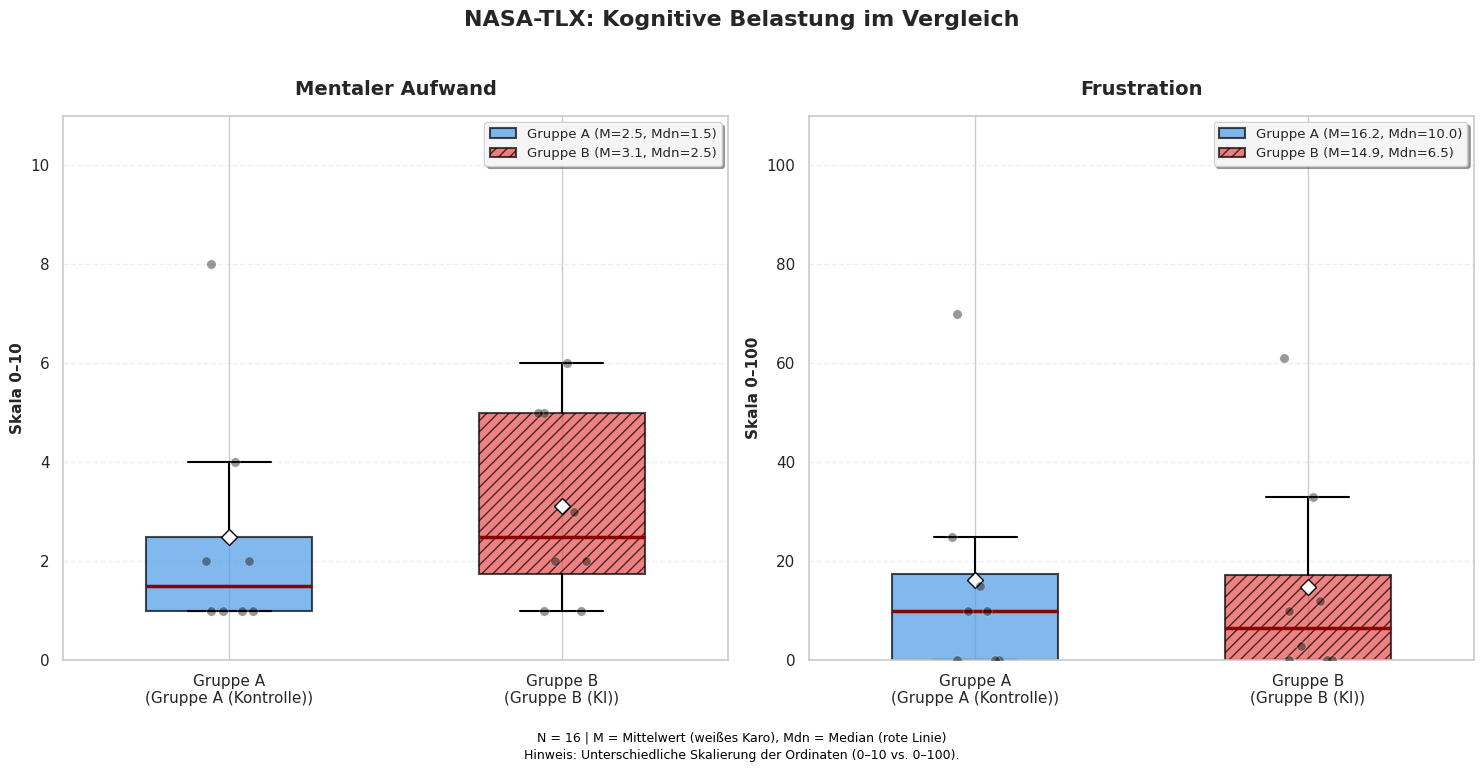

In [67]:
# ===== GRAFIK 7: NASA-TLX (Individuelle Skalierung & Best Practice) =====
print('\n📊 Generiere Grafik 7 (NASA-TLX mit korrekten Skalen)...')

# Definition der unterschiedlichen Skalen
metrics = [
    ('mental_effort', 'Mentaler Aufwand', 'Skala 0–10', (0, 11)),
    ('frustration', 'Frustration', 'Skala 0–100', (0, 110))
]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax_idx, (metric_col, metric_label, y_label_text, y_lim) in enumerate(metrics):
    ax = axes[ax_idx]
    valid_data = evaluations[[metric_col, 'group']].dropna()
    legend_handles = []
    
    for i, group in enumerate(['A', 'B']):
        data = valid_data[valid_data['group'] == group][metric_col]
        m_val = data.mean()
        mdn_val = data.median()
        
        # Boxplot mit weißem Diamanten für den Mittelwert (M)
        bp = ax.boxplot(
            [data], positions=[i], widths=0.5, patch_artist=True,
            showmeans=True,
            showfliers=False,
            meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='white', markersize=8),
            boxprops=dict(facecolor=GROUP_COLORS[group], edgecolor='black', linewidth=1.5, alpha=0.7, hatch=GROUP_HATCH[group]),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='darkred', linewidth=2.5),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=7, alpha=0.5)
        )
        
        # Legende mit M und Mdn (Best Practice)
        l_text = f'Gruppe {group} (M={m_val:.1f}, Mdn={mdn_val:.1f})'
        bp['boxes'][0].set_label(l_text)
        legend_handles.append(bp['boxes'][0])
        
        # Jitter-Punkte
        np.random.seed(42)
        jitter = np.random.uniform(-0.08, 0.08, size=len(data))
        ax.scatter(i + jitter, data, color='black', edgecolors='white', 
                   linewidths=0.5, s=45, alpha=0.4, zorder=3)
    
    # Achsen-Konfiguration (individuell pro Subplot)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'Gruppe {g}\n({GROUP_LABELS[g]})' for g in ['A', 'B']], fontsize=11)
    ax.set_ylabel(y_label_text, fontsize=11, fontweight='bold')
    ax.set_title(metric_label, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylim(y_lim)
    
    ax.yaxis.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Legende positionieren (unten rechts, da dort meist Platz ist)
    ax.legend(handles=legend_handles, loc='upper right', fontsize=9.5, 
              frameon=True, shadow=True, facecolor='white', framealpha=0.9)

fig.suptitle('NASA-TLX: Kognitive Belastung im Vergleich', fontsize=16, fontweight='bold', y=1.02)

# Optimierte Fußnote
footer = (
    f"N = {len(evaluations)} | M = Mittelwert (weißes Karo), Mdn = Median (rote Linie)\n"
    "Hinweis: Unterschiedliche Skalierung der Ordinaten (0–10 vs. 0–100)."
)
fig.text(0.5, -0.05, footer, ha='center', fontsize=9, color='black', linespacing=1.5)

plt.tight_layout()
out_path = OUTPUT_DIR / 'q_eval_nasa_tlx_by_group.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()


📊 Generiere Grafik: Usability (SUS) und Weiterempfehlung (NPS) - Best Practice...


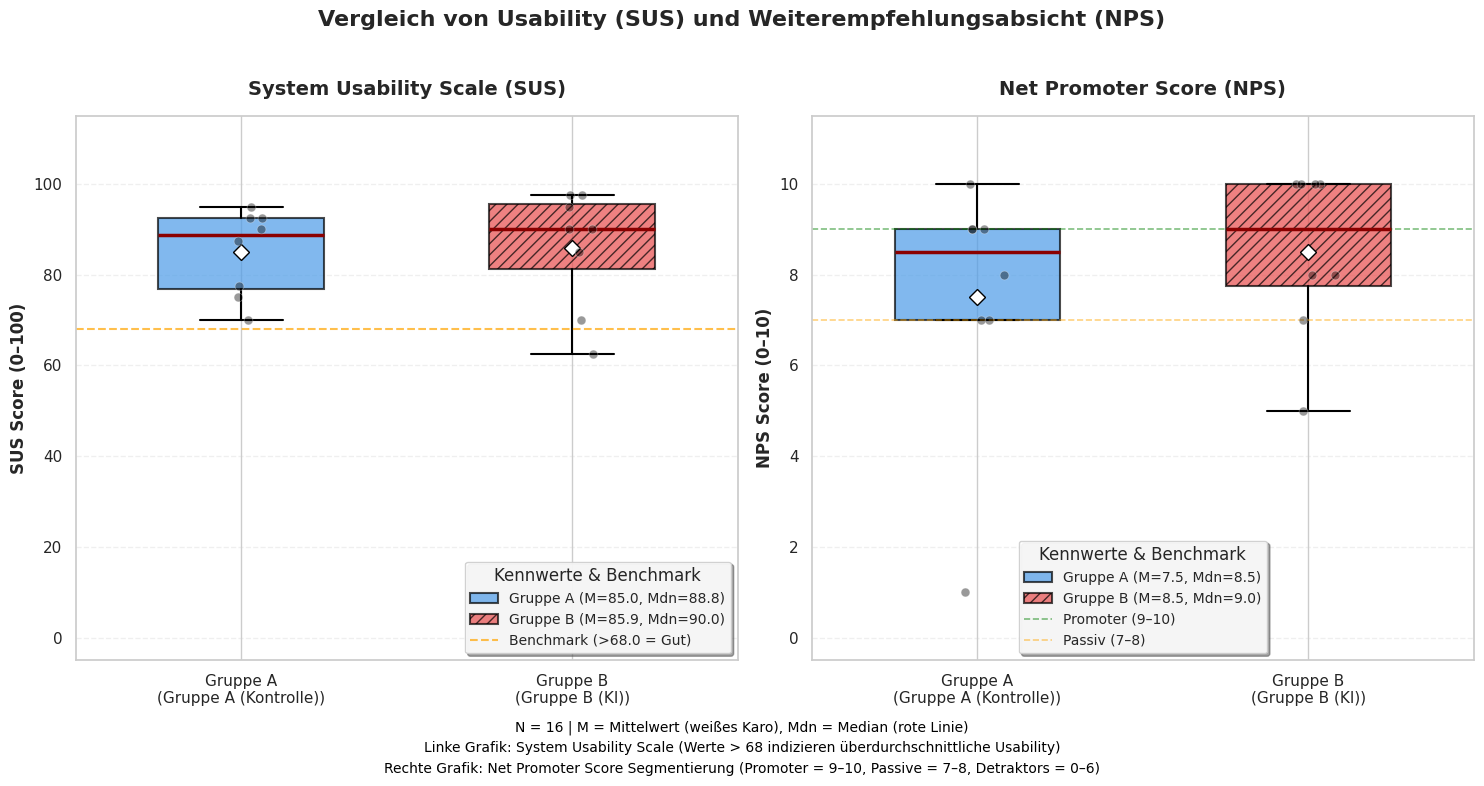

In [68]:
import json

# 1. Berechnung sicherstellen (falls noch nicht geschehen)
SUS_SCORE_MAPPING = {
    'sus_1': 1, 'sus_3': 1, 'sus_5': 1, 'sus_7': 1, 'sus_9': 1,
    'sus_2': -1, 'sus_4': -1, 'sus_6': -1, 'sus_8': -1, 'sus_10': -1
}

def parse_sus_score(raw_json_str):
    try:
        data = json.loads(raw_json_str)
        sus_values = data.get('susValues', {})
        if not sus_values: return None
        total = 0
        for key, multiplier in SUS_SCORE_MAPPING.items():
            value = sus_values.get(key)
            if value is None: return None
            total += (value - 1) if multiplier == 1 else (5 - value)
        return total * 2.5
    except: return None

# Spalte berechnen
evaluations['sus_score'] = evaluations['raw_data_json'].apply(parse_sus_score)

# 2. Grafik generieren (SUS + NPS in einem Doppel-Plot)
print('\n📊 Generiere Grafik: Usability (SUS) und Weiterempfehlung (NPS) - Best Practice...')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Metriken Definition: (Spaltenname, Titel, Y-Achse, Y-Limits)
metrics = [
    ('sus_score', 'System Usability Scale (SUS)', 'SUS Score (0–100)', (-5, 115)),
    ('nps_score', 'Net Promoter Score (NPS)', 'NPS Score (0–10)', (-0.5, 11.5))
]

for ax_idx, (metric_col, metric_label, y_label, y_lim) in enumerate(metrics):
    ax = axes[ax_idx]
    valid_data = evaluations[evaluations[metric_col].notna()]
    legend_handles = []
    
    for i, group in enumerate(['A', 'B']):
        data = valid_data[valid_data['group'] == group][metric_col].dropna()
        m_val = data.mean()
        mdn_val = data.median()
        
        # Boxplot mit weißem Diamanten für den Mittelwert (M)
        bp = ax.boxplot(
            [data], positions=[i+1], widths=0.5, patch_artist=True,
            showmeans=True,
            showfliers=False,
            meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='white', markersize=8),
            boxprops=dict(facecolor=GROUP_COLORS[group], edgecolor='black', linewidth=1.5, alpha=0.7, hatch=GROUP_HATCH[group]),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='darkred', linewidth=2.5),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=6, alpha=0.5)
        )
        
        # Legenden-Label mit M und Mdn
        l_label = f'Gruppe {group} (M={m_val:.1f}, Mdn={mdn_val:.1f})'
        bp['boxes'][0].set_label(l_label)
        legend_handles.append(bp['boxes'][0])
        
        # Jitter-Punkte
        np.random.seed(42 + ax_idx)
        jitter = np.random.normal(0, 0.04, size=len(data))
        ax.scatter([i+1] + jitter, data, color='black', s=40, edgecolors='white', linewidth=0.5, alpha=0.4, zorder=3)
        
    # Spezifische Benchmarks
    if metric_col == 'sus_score':
        benchmark = ax.axhline(y=68, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Benchmark (>68.0 = Gut)')
        legend_handles.append(benchmark)
        leg_loc = 'lower right'
    elif metric_col == 'nps_score':
        p_line = ax.axhline(y=9, color='green', linestyle='--', linewidth=1.2, alpha=0.5, label='Promoter (9–10)')
        pass_line = ax.axhline(y=7, color='orange', linestyle='--', linewidth=1.2, alpha=0.5, label='Passiv (7–8)')
        legend_handles.extend([p_line, pass_line])
        leg_loc = 'lower center' if ax_idx == 1 else 'lower right'

    # Achsen & Design pro Subplot
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'Gruppe {g}\n({GROUP_LABELS[g]})' for g in ['A', 'B']], fontsize=11)
    ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
    ax.set_title(metric_label, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylim(y_lim)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Legende als Overlay
    ax.legend(handles=legend_handles, loc=leg_loc, fontsize=10, title="Kennwerte & Benchmark",
              frameon=True, shadow=True, facecolor='white', framealpha=0.9)

# Haupttitel & Fußnote
fig.suptitle('Vergleich von Usability (SUS) und Weiterempfehlungsabsicht (NPS)', fontsize=16, fontweight='bold', y=1.02)
footer = (
    f"N = {len(valid_data)} | M = Mittelwert (weißes Karo), Mdn = Median (rote Linie)\n"
    "Linke Grafik: System Usability Scale (Werte > 68 indizieren überdurchschnittliche Usability)\n"
    "Rechte Grafik: Net Promoter Score Segmentierung (Promoter = 9–10, Passive = 7–8, Detraktors = 0–6)"
)
fig.text(0.5, -0.07, footer, ha='center', fontsize=10, color='black', linespacing=1.6)

plt.tight_layout()
out_path = OUTPUT_DIR / '..' / 'q_eval_sus_nps_by_group.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()


📊 Generiere: UEQ-S Items Profile (Profil-Linien, 1 bis 7)...


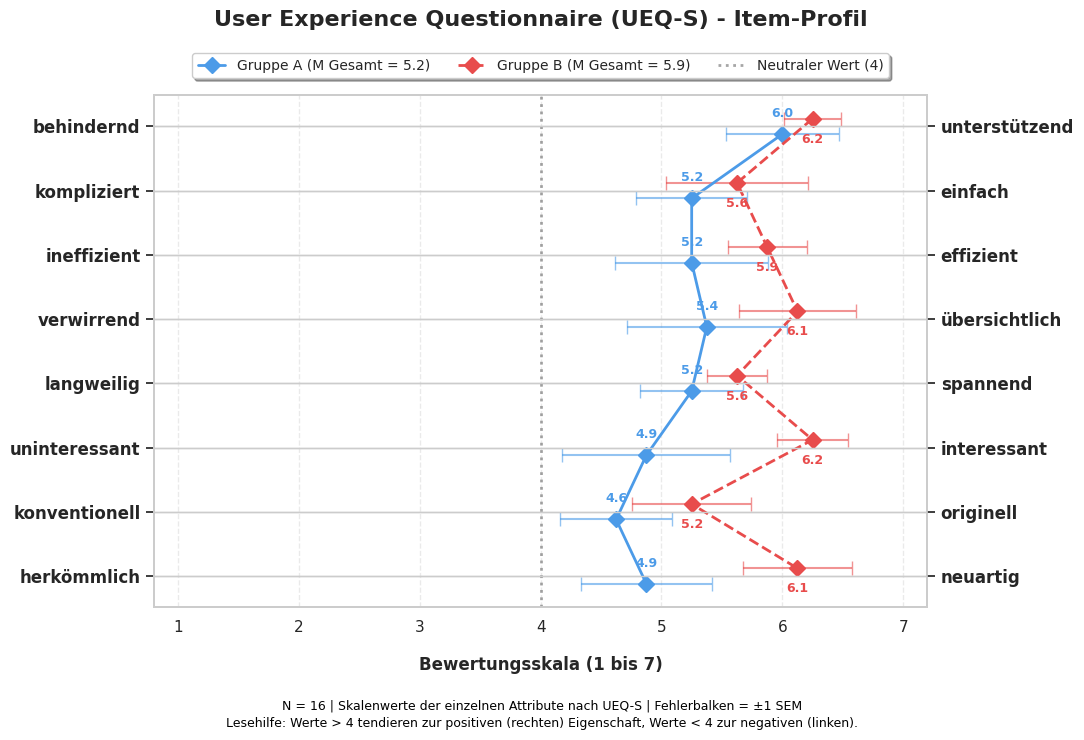

✅ Gespeichert: /home/shaco/bachelor/python-bootcamp-4c-id/analysis/output/q_eval_ueqs_items_profile_1_to_7.png


In [69]:
# ===== GRAFIK 11: UEQ-S Item Profile (Dot-Plot Variante, Originalskala 1-7, deutsch) =====
print('\n📊 Generiere: UEQ-S Items Profile (Profil-Linien, 1 bis 7)...')

# Falls in vorherigen Zellen nicht mehr existent, hier nochmal absichern:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_ueq_items_local(raw_json_str):
    try:
        data = json.loads(raw_json_str)
        return data.get('ueqValues', {}) or None
    except:
        return None

evaluations['ueq_parsed'] = evaluations['raw_data_json'].apply(parse_ueq_items_local)
evaluations_with_ueq = evaluations[evaluations['ueq_parsed'].notna()].copy()

# 1. Deutsche Begriffspaare (links / rechts) der 8 Skalen
ueq_item_keys = ['ueq_1', 'ueq_2', 'ueq_3', 'ueq_4', 'ueq_5', 'ueq_6', 'ueq_7', 'ueq_8']
item_pairs = [
    ("behindernd", "unterstützend"),
    ("kompliziert", "einfach"),
    ("ineffizient", "effizient"),
    ("verwirrend", "übersichtlich"),
    ("langweilig", "spannend"),
    ("uninteressant", "interessant"),
    ("konventionell", "originell"),
    ("herkömmlich", "neuartig")
]

ueq_items = []
for group in ['A', 'B']:
    group_data = evaluations_with_ueq[evaluations_with_ueq['group'] == group]
    for idx, key in enumerate(ueq_item_keys):
        # Rohwerte extrahieren (Werte auf Originalskala 1 bis 7 belassen!)
        vals = [d.get(key) for d in group_data['ueq_parsed'] if d and d.get(key) is not None]
        if vals:
            ueq_items.append({
                'group': group,
                'idx': idx,
                'mean': np.mean(vals),
                'sem': np.std(vals) / np.sqrt(len(vals)) if len(vals) > 0 else 0
            })

df_ueq_plot = pd.DataFrame(ueq_items)

# 2. Plotting als Profil-Liniendiagramm
fig, ax = plt.subplots(figsize=(11, 7))

# Wir ordnen die Items so an, dass Item 1 (Idx 0) ganz oben im Plot steht
y_pos = np.arange(len(item_pairs))[::-1]
legend_handles = []

for group in ['A', 'B']:
    data = df_ueq_plot[df_ueq_plot['group'] == group].sort_values('idx')
    
    # minimaler Y-Offset zur besseren Unterscheidung der Fehlerbalken
    offset = 0.12 if group == 'B' else -0.12
    y_adjusted = y_pos + offset
    
    # Profil-Linie mit Punkten
    linestyle = '--' if group == 'B' else '-'
    line, = ax.plot(data['mean'], y_adjusted, marker='D', markersize=8, linewidth=2,
             label=f"Gruppe {group} (M Gesamt = {data['mean'].mean():.1f})", 
             color=GROUP_COLORS[group], linestyle=linestyle, zorder=4)
    
    # Fehlerbalken
    ax.errorbar(data['mean'], y_adjusted, xerr=data['sem'], fmt='none', 
                c=GROUP_COLORS[group], capsize=5, elinewidth=1.5, alpha=0.6, zorder=3)
    
    # Daten-Labels leicht über/unter den Punkten
    for j, val in enumerate(data['mean']):
        text_y_offset = -0.32 if group == 'B' else 0.32
        ax.text(val, y_adjusted[j] + text_y_offset, f'{val:.1f}', 
                va='center', ha='center', fontsize=9, fontweight='bold', color=GROUP_COLORS[group])
        
    legend_handles.append(line)

# Rechte und Linke Y-Achsen-Labels definieren
left_labels = [pair[0] for pair in item_pairs]
right_labels = [pair[1] for pair in item_pairs]

ax.set_yticks(y_pos)
ax.set_yticklabels(left_labels, fontsize=12, fontweight='bold', ha='right')

ax_right = ax.twinx()
ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(y_pos)
ax_right.set_yticklabels(right_labels, fontsize=12, fontweight='bold', ha='left')

# X-Achse und Benchmarks
ax.set_xlim(0.8, 7.2)
ax.set_xticks([1, 2, 3, 4, 5, 6, 7])
ax.set_xlabel('Bewertungsskala (1 bis 7)', fontsize=12, fontweight='bold', labelpad=15)
ax.set_title('User Experience Questionnaire (UEQ-S) - Item-Profil', fontsize=16, fontweight='bold', pad=50)

neutral_line = ax.axvline(4, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='Neutraler Wert (4)')

# Grid nur für X einblenden
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

# Legende positionieren (oberhalb des Graphen)
ax.legend(handles=legend_handles + [neutral_line], loc='lower center', bbox_to_anchor=(0.5, 1.02), 
          ncol=3, fontsize=10, shadow=True, frameon=True)

# Fußnote
footer = (
    f"N = {len(evaluations_with_ueq)} | Skalenwerte der einzelnen Attribute nach UEQ-S | Fehlerbalken = ±1 SEM\n"
    "Lesehilfe: Werte > 4 tendieren zur positiven (rechten) Eigenschaft, Werte < 4 zur negativen (linken)."
)
fig.text(0.5, -0.05, footer, ha='center', fontsize=9, color='black', linespacing=1.5)

plt.tight_layout()
out_path = OUTPUT_DIR / 'q_eval_ueqs_items_profile_1_to_7.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'✅ Gespeichert: {out_path}')


📊 Generiere Grafik 18 (KI-Chat Nutzung gesendet, Gruppe B)...


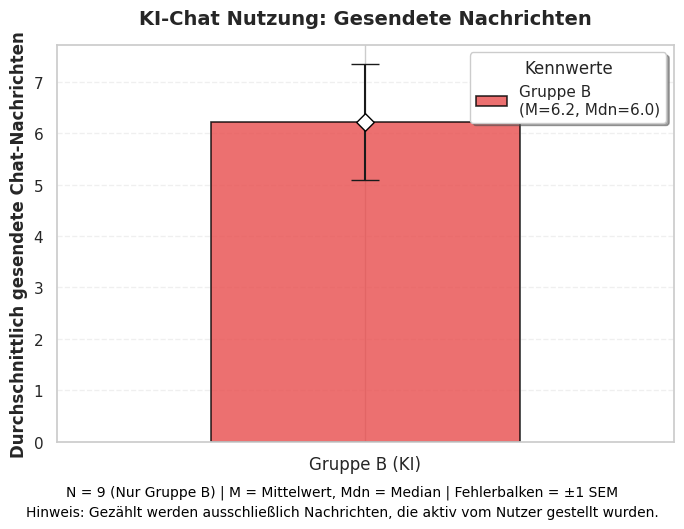

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== GRAFIK 18: KI-Chat-Nutzung (Nur gesendete Nachrichten, Nur Gruppe B) - Best Practice =====
print('\n📊 Generiere Grafik 18 (KI-Chat Nutzung gesendet, Gruppe B)...')

# 1. Chat-Daten laden und filtern
chat_path = EXPORT_DIR / 'study_chat_messages-unfiltered-2026-03-03.csv'
if not chat_path.exists():
    chat_path = newest_file('study_chat_messages-*.csv')

if chat_path:
    chat_df = pd.read_csv(chat_path)
    # Nur Nachrichten, die vom User gesendet wurden
    user_msgs = chat_df[chat_df['is_user'] == 1].copy()
    
    # Anzahl pro Teilnehmer berechnen
    chat_counts = user_msgs.groupby('participant_id').size().reset_index(name='chat_messages_sent')
    
    # Mit Teilnehmern mergen, um auch diejenigen mit 0 Nachrichten zu erfassen (Gruppe B)
    participants_b = participants[participants['group'] == 'B'].copy()
    ki_data_b = participants_b.merge(chat_counts, on='participant_id', how='left')
    ki_data_b['chat_messages_sent'] = ki_data_b['chat_messages_sent'].fillna(0)
    
    # Bereite die Daten so vor, dass sie für nachfolgende Chart-Stücke (Grafik 15/16) kompatibel sind
    # (Diese nutzten bisher ki_data['chat_messages'])
    ki_data = participants[['participant_id', 'group']].copy()
    ki_data = ki_data.merge(chat_counts, on='participant_id', how='left')
    ki_data.rename(columns={'chat_messages_sent': 'chat_messages'}, inplace=True)
    ki_data['chat_messages'] = ki_data['chat_messages'].fillna(0)
    
    # Die Korrelations-Dataframes für Grafik 15 und 16 herstellen:
    chat_completion = participants.merge(ki_data[['participant_id', 'chat_messages']], on='participant_id', how='left')
    chat_errors = chat_completion.copy()
else:
    print("⚠️ Warnung: Chat-Daten nicht gefunden. Verwende Dummy-Daten für Grafik.")
    ki_data_b = participants[participants['group'] == 'B'].copy()
    ki_data_b['chat_messages_sent'] = 0
    ki_data = participants.copy()
    ki_data['chat_messages'] = 0
    chat_completion = ki_data.copy()
    chat_errors = ki_data.copy()

# Statistiken berechnen
chat_mean = ki_data_b['chat_messages_sent'].mean()
chat_median = ki_data_b['chat_messages_sent'].median()
chat_sem = ki_data_b['chat_messages_sent'].sem()

# Plot erstellen
fig, ax = plt.subplots(figsize=(7, 5))

color_b = GROUP_COLORS['B'] if 'GROUP_COLORS' in globals() else 'green'

# Balken für Gruppe B
bar_chat = ax.bar(0, chat_mean, yerr=chat_sem, 
                  color=color_b, alpha=0.8, capsize=10, width=0.5, edgecolor='black', linewidth=1.2)

# Best Practice: Weißes Karo für den Mittelwert (M)
ax.scatter(0, chat_mean, marker='D', s=80, color='white', edgecolor='black', zorder=5)

# Legende unten rechts
ax.legend([bar_chat], [f"Gruppe B\n(M={chat_mean:.1f}, Mdn={chat_median:.1f})"], 
          loc='upper right', shadow=True, title="Kennwerte")

ax.set_xticks([0])
ax.set_xticklabels(['Gruppe B (KI)'], fontsize=12)
ax.set_ylabel('Durchschnittlich gesendete Chat-Nachrichten', fontsize=12, fontweight='bold')
ax.set_title('KI-Chat Nutzung: Gesendete Nachrichten', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# X-Achse limitieren für schmale Balken
ax.set_xlim(-0.5, 0.5)

# Best Practice: Saubere Fußnote
n_b = len(ki_data_b)
footer = (f"N = {n_b} (Nur Gruppe B) | M = Mittelwert, Mdn = Median | Fehlerbalken = ±1 SEM\n"
          f"Hinweis: Gezählt werden ausschließlich Nachrichten, die aktiv vom Nutzer gestellt wurden.")
fig.text(0.5, -0.05, footer, ha='center', fontsize=10, color='black', linespacing=1.5)

plt.tight_layout()
import pathlib
out_path = OUTPUT_DIR / 'ki_usage_chat_sent_group_b.png' if 'OUTPUT_DIR' in globals() else pathlib.Path('ki_usage_chat_sent_group_b.png')
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()


📊 Generiere Grafik 13 (Diskret & mit Daten-Labels)...
ℹ️ Datengrundlage Fehler/Step: 221 Zeilen | Nullwerte gesamt: 80.1%
   Gruppe A: Nullwerte = 83.0% | M=0.28, Mdn=0.00
   Gruppe B: Nullwerte = 77.4% | M=0.61, Mdn=0.00


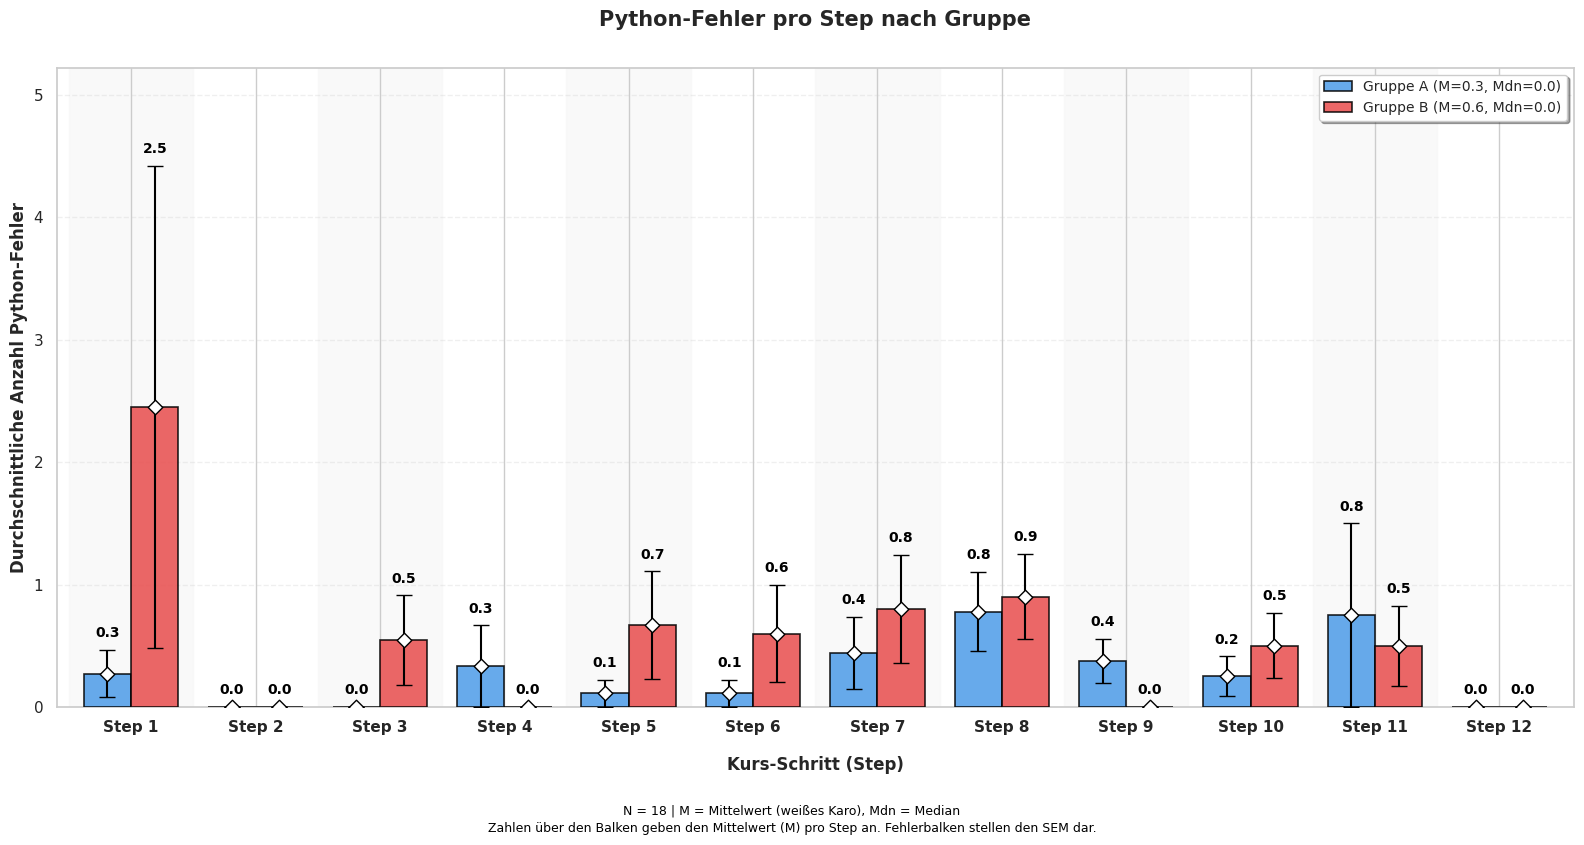

In [71]:
# ===== GRAFIK 13: Python-Fehler pro Step (Vollständig mit Labels) =====
print('\n📊 Generiere Grafik 13 (Diskret & mit Daten-Labels)...')

# Robuste Spalten-Erkennung (je nach Export heißt es step oder step_number)
step_col = 'step' if 'step' in task_level.columns else 'step_number' if 'step_number' in task_level.columns else None
if step_col is None:
    raise KeyError("Weder 'step' noch 'step_number' in task_level vorhanden.")
if 'python_errors' not in task_level.columns:
    raise KeyError("Spalte 'python_errors' fehlt in task_level.")

plot_df = task_level.copy()
plot_df[step_col] = pd.to_numeric(plot_df[step_col], errors='coerce')
plot_df['python_errors'] = pd.to_numeric(plot_df['python_errors'], errors='coerce')
plot_df = plot_df.dropna(subset=[step_col, 'group', 'python_errors']).copy()

# Kurze Plausibilitätsdiagnose der Nullwerte
zero_share_total = (plot_df['python_errors'] == 0).mean()
print(f"ℹ️ Datengrundlage Fehler/Step: {len(plot_df)} Zeilen | Nullwerte gesamt: {zero_share_total:.1%}")
for g in ['A', 'B']:
    g_data = plot_df[plot_df['group'] == g]['python_errors']
    if len(g_data) > 0:
        print(f"   Gruppe {g}: Nullwerte = {(g_data == 0).mean():.1%} | M={g_data.mean():.2f}, Mdn={g_data.median():.2f}")

# 1. Daten aggregieren (Mean, Median und SEM für Best Practice)
error_stats = plot_df.groupby([step_col, 'group'])['python_errors'].agg(['mean', 'median', 'sem']).reset_index()

fig, ax = plt.subplots(figsize=(16, 8))
all_steps = sorted(error_stats[step_col].unique())
bar_width = 0.38

# 2. ZEBRA-SHADING (Vertikale Korridore)
for i, step in enumerate(all_steps):
    if i % 2 == 0:
        ax.axvspan(step - 0.5, step + 0.5, color='#f8f8f8', zorder=0, alpha=0.8)

legend_handles = []

# 3. GRUPPIERTE BALKEN UND LABELS
for i, group in enumerate(['A', 'B']):
    data = error_stats[error_stats['group'] == group]
    positions = data[step_col] + (-bar_width / 2 if group == 'A' else bar_width / 2)

    # Balken
    bars = ax.bar(
        positions,
        data['mean'],
        width=bar_width,
        label=f"Gruppe {group}",
        color=GROUP_COLORS[group],
        edgecolor='black',
        linewidth=1.2,
        alpha=0.85,
        zorder=3
    )

    # Fehlerbalken (SEM)
    sem_vals = data['sem'].fillna(0)
    ax.errorbar(
        positions,
        data['mean'],
        yerr=sem_vals,
        fmt='none',
        c='black',
        capsize=6,
        elinewidth=1.5,
        zorder=4
    )

    # Weißer Diamant für den Mittelwert (M)
    ax.scatter(
        positions,
        data['mean'],
        marker='D',
        s=55,
        color='white',
        edgecolor='black',
        label='_nolegend_',
        zorder=5
    )

    # Daten-Labels über den Balken
    for j, val in enumerate(data['mean']):
        label_y_pos = val + sem_vals.iloc[j] + 0.08
        ax.text(
            positions.iloc[j],
            label_y_pos,
            f'{val:.1f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='black',
            zorder=6
        )

    # Legenden-Eintrag mit M und Mdn (Best Practice)
    group_m = data['mean'].mean()
    group_mdn = data['median'].median()
    bars.set_label(f"Gruppe {group} (M={group_m:.1f}, Mdn={group_mdn:.1f})")
    legend_handles.append(bars)

# 4. ACHSEN-KONFIGURATION
ax.set_xticks(all_steps)
ax.set_xticklabels([f"Step {int(s)}" for s in all_steps], fontsize=11, fontweight='bold')
ax.set_xlim(min(all_steps) - 0.6, max(all_steps) + 0.6)

ax.set_xlabel('Kurs-Schritt (Step)', fontsize=12, fontweight='bold', labelpad=15)
ax.set_ylabel('Durchschnittliche Anzahl Python-Fehler', fontsize=12, fontweight='bold')
ax.set_title('Python-Fehler pro Step nach Gruppe', fontsize=15, fontweight='bold', pad=30)

# Y-Achse Puffer für Labels
ax.set_ylim(0, error_stats['mean'].max() + error_stats['sem'].fillna(0).max() + 0.8)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=1)

# Legende und Fußnote
ax.legend(handles=legend_handles, loc='upper right', fontsize=10, shadow=True, frameon=True)

footer = (
    f"N = {len(plot_df['participant_id'].unique())} | M = Mittelwert (weißes Karo), Mdn = Median\n"
    "Zahlen über den Balken geben den Mittelwert (M) pro Step an. Fehlerbalken stellen den SEM dar."
)
fig.text(0.5, -0.05, footer, ha='center', fontsize=9, color='black', linespacing=1.5)

plt.tight_layout()
out_path = OUTPUT_DIR / 'errors_per_step_by_group_labeled.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()


📊 Generiere Grafik 14 (Diskret, Vollständig & mit Daten-Labels)...


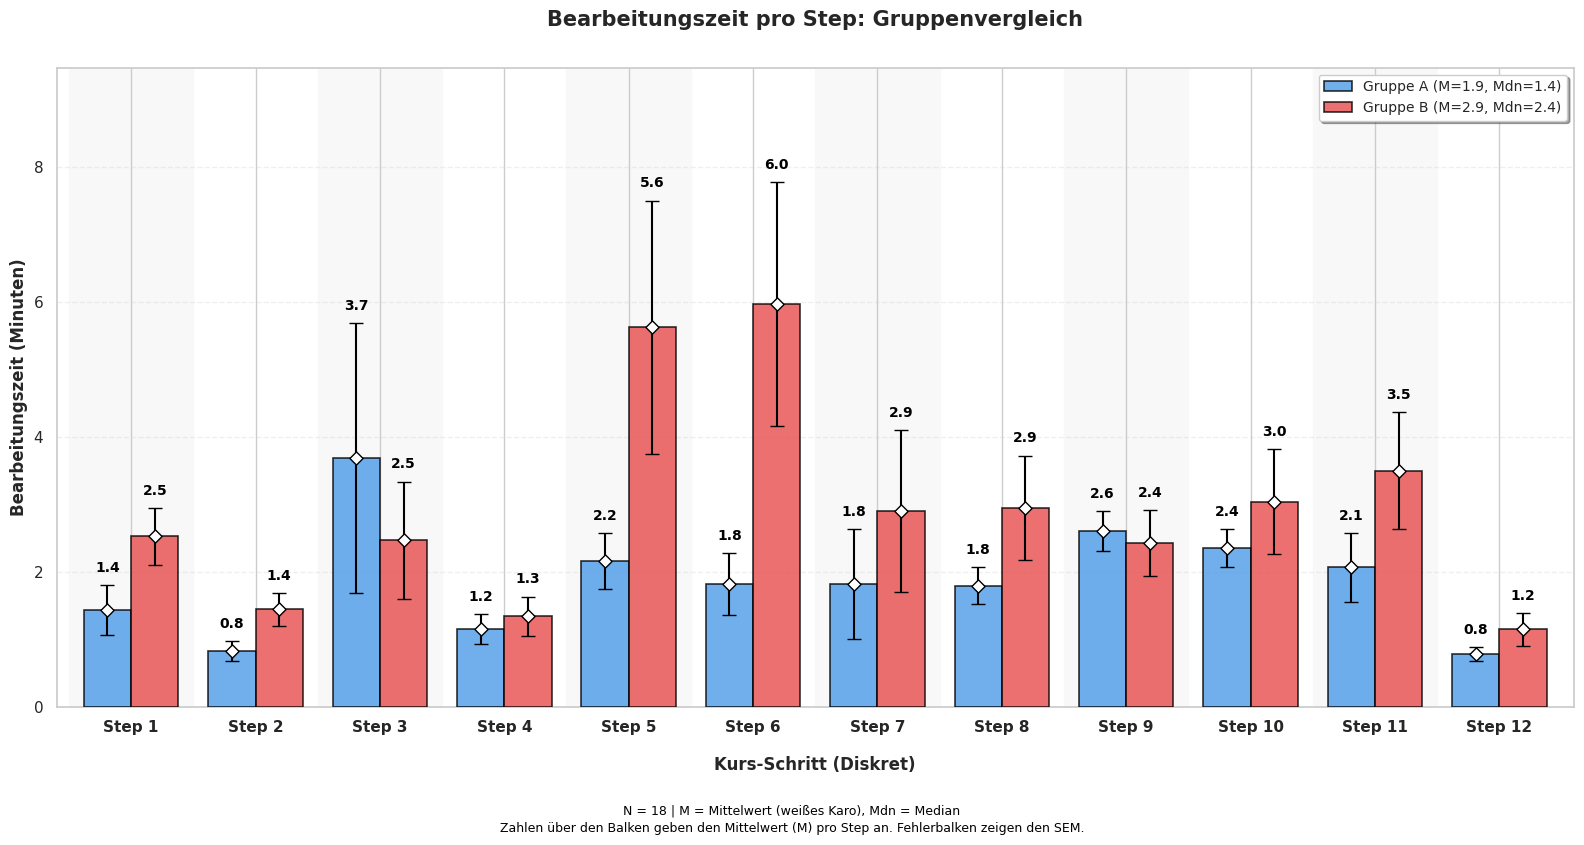

In [72]:
# ===== GRAFIK 14: Bearbeitungszeit pro Step (Vollständig mit Labels) =====
print('\n📊 Generiere Grafik 14 (Diskret, Vollständig & mit Daten-Labels)...')

# Robuste Spalten-Erkennung (je nach Export heißt es step oder step_number)
step_col = 'step' if 'step' in task_level.columns else 'step_number' if 'step_number' in task_level.columns else None
if step_col is None:
    raise KeyError("Weder 'step' noch 'step_number' in task_level vorhanden.")
if 'time_on_task_minutes' not in task_level.columns:
    raise KeyError("Spalte 'time_on_task_minutes' fehlt in task_level.")

plot_df = task_level.copy()
plot_df[step_col] = pd.to_numeric(plot_df[step_col], errors='coerce')
plot_df['time_on_task_minutes'] = pd.to_numeric(plot_df['time_on_task_minutes'], errors='coerce')
plot_df = plot_df.dropna(subset=[step_col, 'group', 'time_on_task_minutes']).copy()

# 1. Daten aggregieren
time_stats = plot_df.groupby([step_col, 'group'])['time_on_task_minutes'].agg(['mean', 'median', 'sem']).reset_index()

fig, ax = plt.subplots(figsize=(16, 8))
all_steps = sorted(time_stats[step_col].unique())
bar_width = 0.38

# 2. ZEBRA-SHADING (Hintergrund-Korridore)
for i, step in enumerate(all_steps):
    if i % 2 == 0:
        ax.axvspan(step - 0.5, step + 0.5, color='#f8f8f8', zorder=0)

legend_handles = []

# 3. BALKEN UND LABELS ZEICHNEN
for i, group in enumerate(['A', 'B']):
    data = time_stats[time_stats['group'] == group]
    positions = data[step_col] + (-bar_width / 2 if group == 'A' else bar_width / 2)

    # Die Balken
    bars = ax.bar(
        positions,
        data['mean'],
        width=bar_width,
        label=f"Gruppe {group}",
        color=GROUP_COLORS[group],
        edgecolor='black',
        linewidth=1.2,
        alpha=0.8,
        zorder=3
    )

    # Fehlerbalken (SEM)
    sem_vals = data['sem'].fillna(0)
    ax.errorbar(
        positions,
        data['mean'],
        yerr=sem_vals,
        fmt='none',
        c='black',
        capsize=5,
        elinewidth=1.5,
        zorder=4
    )

    # Weißer Diamant für den Mittelwert (M)
    ax.scatter(
        positions,
        data['mean'],
        marker='D',
        s=45,
        color='white',
        edgecolor='black',
        label='_nolegend_',
        zorder=5
    )

    # Durchschnittswerte über den Balken/Fehlerbalken
    for j, val in enumerate(data['mean']):
        label_y_pos = val + sem_vals.iloc[j] + 0.15
        ax.text(
            positions.iloc[j],
            label_y_pos,
            f'{val:.1f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='black',
            zorder=6
        )

    # Legenden-Handling (M und Mdn Best Practice)
    overall_m = data['mean'].mean()
    overall_mdn = data['median'].median()
    bars.set_label(f"Gruppe {group} (M={overall_m:.1f}, Mdn={overall_mdn:.1f})")
    legend_handles.append(bars)

# 4. ACHSEN-KONFIGURATION
ax.set_xticks(all_steps)
ax.set_xticklabels([f"Step {int(s)}" for s in all_steps], fontsize=11, fontweight='bold')
ax.set_xlim(min(all_steps) - 0.6, max(all_steps) + 0.6)

# Labels & Titel
ax.set_xlabel('Kurs-Schritt (Diskret)', fontsize=12, fontweight='bold', labelpad=15)
ax.set_ylabel('Bearbeitungszeit (Minuten)', fontsize=12, fontweight='bold')
ax.set_title('Bearbeitungszeit pro Step: Gruppenvergleich', fontsize=15, fontweight='bold', pad=30)

# Y-Achse Puffer für Labels oben geben
ax.set_ylim(0, time_stats['mean'].max() + time_stats['sem'].fillna(0).max() + 1.5)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=1)

# Legende und Fußnote
ax.legend(handles=legend_handles, loc='upper right', fontsize=10, shadow=True, frameon=True)

footer = (
    f"N = {len(plot_df['participant_id'].unique())} | M = Mittelwert (weißes Karo), Mdn = Median\n"
    "Zahlen über den Balken geben den Mittelwert (M) pro Step an. Fehlerbalken zeigen den SEM."
)
fig.text(0.5, -0.05, footer, ha='center', fontsize=9, color='black', linespacing=1.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'time_per_step_by_group_labeled.png', dpi=200, bbox_inches='tight')
plt.show()


📊 Generiere Grafik 16 (Korrelation nur Gruppe B)...


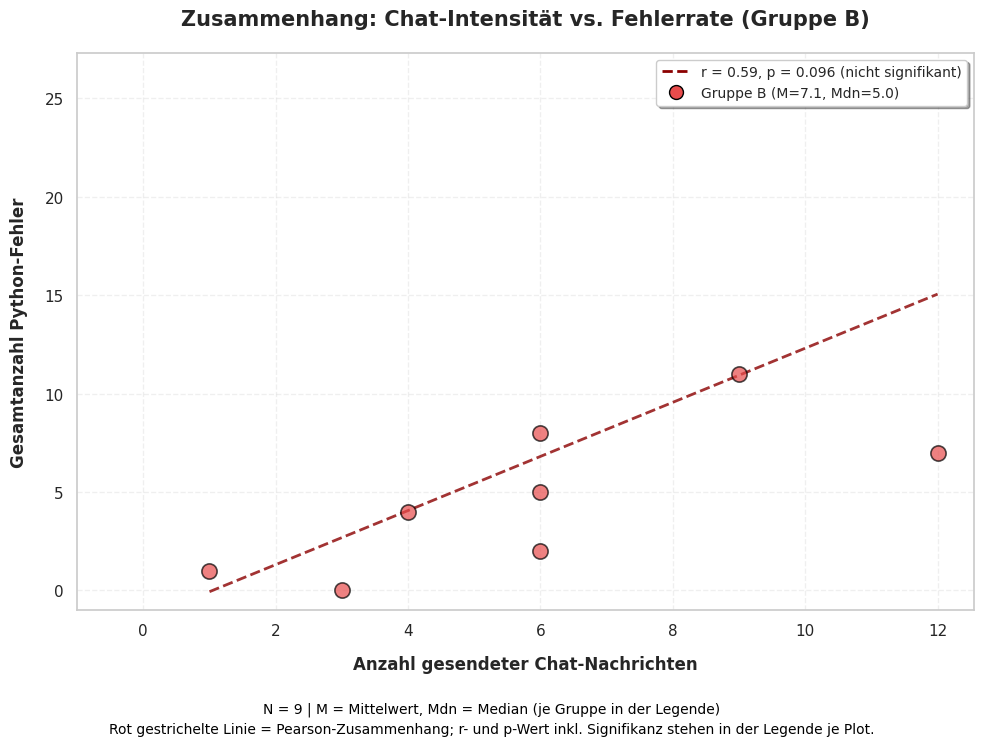

In [73]:
import scipy.stats as stats
from matplotlib.lines import Line2D

print('\n📊 Generiere Grafik 16 (Korrelation nur Gruppe B)...')

# 1. Daten filtern: Nur Gruppe B, da nur sie den Chat nutzen konnten
data_b = chat_errors[chat_errors['group'] == 'B'].dropna(subset=['chat_messages', 'bmi_python_errors'])

# 2. Korrelation berechnen (Pearson r und p-Wert)
r_val, p_val = stats.pearsonr(data_b['chat_messages'], data_b['bmi_python_errors'])
significance = "signifikant" if p_val < 0.05 else "nicht signifikant"

fig, ax = plt.subplots(figsize=(10, 7))

# 3. Scatterplot für Gruppe B
ax.scatter(
    data_b['chat_messages'], data_b['bmi_python_errors'],
    s=120, alpha=0.7, color=GROUP_COLORS['B'],
    edgecolors='black', linewidth=1.2,
    zorder=3
)

# 4. Regressionslinie zeichnen
m, b = np.polyfit(data_b['chat_messages'], data_b['bmi_python_errors'], 1)
xs = np.linspace(data_b['chat_messages'].min(), data_b['chat_messages'].max(), 100)
ax.plot(
    xs, m * xs + b,
    color='darkred', linestyle='--', linewidth=2, alpha=0.8,
    zorder=2
)

# Achsen & Design
ax.set_xlabel('Anzahl gesendeter Chat-Nachrichten', fontsize=12, fontweight='bold', labelpad=12)
ax.set_ylabel('Gesamtanzahl Python-Fehler', fontsize=12, fontweight='bold', labelpad=12)
ax.set_title('Zusammenhang: Chat-Intensität vs. Fehlerrate (Gruppe B)', fontsize=15, fontweight='bold', pad=20)

# X-Achse bei 0 starten lassen
ax.set_xlim(left=-1)
ax.set_ylim(bottom=-1)

ax.grid(axis='both', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Legende einheitlich: r/p/Signifikanz + M/Mdn
m_b = data_b['bmi_python_errors'].mean()
mdn_b = data_b['bmi_python_errors'].median()
legend_handles = [
    Line2D([0], [0], color='darkred', linestyle='--', linewidth=2,
           label=f'r = {r_val:.2f}, p = {p_val:.3f} ({significance})'),
    Line2D([0], [0], marker='o', linestyle='None', markersize=10,
           markerfacecolor=GROUP_COLORS['B'], markeredgecolor='black',
           label=f'Gruppe B (M={m_b:.1f}, Mdn={mdn_b:.1f})')
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=10, frameon=True, shadow=True)

# Fußnote einheitlich zu den anderen Korrelationsplots
footer = (
    f'N = {len(data_b)} | M = Mittelwert, Mdn = Median (je Gruppe in der Legende)\n'
    'Rot gestrichelte Linie = Pearson-Zusammenhang; r- und p-Wert inkl. Signifikanz stehen in der Legende je Plot.'
)
fig.text(0.5, -0.06, footer, ha='center', fontsize=10, color='black', linespacing=1.5)

plt.tight_layout()
out_path = OUTPUT_DIR / 'chat_vs_errors_correlation_group_b.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

In [74]:
# Bridge: einheitlicher Output-Pfad
from pathlib import Path
if "OUTPUT_DIR" in globals():
    OUT_DIR = OUTPUT_DIR
else:
    OUT_DIR = Path.cwd() / "analysis" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"OUT_DIR gesetzt auf: {OUT_DIR}")


OUT_DIR gesetzt auf: /home/shaco/bachelor/python-bootcamp-4c-id/analysis/output


## Block B: Zusatzanalysen KI-Evaluation (aus Zusatzanalysen Notebook)


# Zusatzanalysen: KI-Evaluation

Spezifische Detailanalysen zur KI-Nutzung in der Python-Bootcamp-Studie.

## Analysen:
1. **Zeit bis zur ersten KI-Anfrage** (Time-to-First-AI, nur Gruppe B)
2. **KI-Fragebogen-Auswertung** (aiUsefulness, aiTrust – nur Gruppe B)
3. **Vollständigkeits-Check Evaluationsbogen** (alle Fragen im Überblick)
4. **Drill-Vielfalt** (Unique Drill IDs, A vs. B)
5. **KI-Anfragen pro Kursschritt** (nur Gruppe B, Pain-Points)
6. **Drill-Schwierigkeit** (Versuche bis Lösung)

---
**Design-Standards:** Gruppe A = Blau (`#4C9BE8`), Gruppe B = Rot (`#E84C4C`, Hatch `///`)  
**Stichprobe:** Gefiltert (num_runs_code > 2)  
**Output:** `analysis/output/neu/`

In [75]:
# === SETUP & IMPORTS ===
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

# === GLOBALE DESIGN-STANDARDS (aus MAIN Notebook Best Practice) ===
GROUP_COLORS = {
    'A': '#4C9BE8',   # Blau (Kontrolle)
    'B': '#E84C4C',   # Rot (KI)
}
GROUP_LABELS = {
    'A': 'Gruppe A (Kontrolle)',
    'B': 'Gruppe B (KI)',
}
GROUP_HATCH = {
    'A': '',
    'B': '///',
}
GROUP_LINESTYLE = {
    'A': '-',
    'B': '--',
}
MEAN_MARKER = dict(marker='D', markeredgecolor='black', markerfacecolor='white', markersize=8)

def add_footer(fig, text, y=-0.05):
    """Gestraffte Fußnote unter Grafik."""
    fig.text(0.5, y, text, ha='center', fontsize=9, color='black', linespacing=1.5,
             style='italic')

print('✅ Design-Standards geladen.')
print(f'  Gruppe A: {GROUP_COLORS["A"]} (Blau, solid)')
print(f'  Gruppe B: {GROUP_COLORS["B"]} (Rot, hatch=///)') 

✅ Design-Standards geladen.
  Gruppe A: #4C9BE8 (Blau, solid)
  Gruppe B: #E84C4C (Rot, hatch=///)


In [ ]:
# === VERZEICHNISSE & DATEI-LADEN ===
BASE = Path.cwd()
candidates = [BASE, BASE.parent, BASE.parent.parent, BASE.parent.parent.parent]
PROJECT_ROOT = None
for c in candidates:
    if (c / 'analysis' / 'exports_anonymized').exists():
        PROJECT_ROOT = c
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(f'analysis/exports_anonymized nicht gefunden. Start-CWD: {BASE}')

EXPORT_DIR = PROJECT_ROOT / 'analysis' / 'exports_anonymized'
# Neuer Unterordner /neu/ für saubere Abgrenzung
OUT_DIR = PROJECT_ROOT / 'analysis' / 'output'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def newest_file(pattern: str):
    files = sorted(EXPORT_DIR.glob(pattern))
    return files[-1] if files else None

# Dateipfade ermitteln
files = {
    'participants': newest_file('study_participants-filtered-*.csv') or newest_file('study_participants-*.csv'),
    'task_level':   newest_file('study_task_level-filtered-*.csv')   or newest_file('study_task_level-*.csv'),
    'event_timeline': newest_file('study_event_timeline-filtered-*.csv') or newest_file('study_event_timeline-unfiltered-*.csv'),
    'chat_messages':  newest_file('study_chat_messages-filtered-*.csv')  or newest_file('study_chat_messages-unfiltered-*.csv'),
    'drill_events':   newest_file('study_drill_events-filtered-*.csv')   or newest_file('study_drill_events-unfiltered-*.csv'),
    'evaluations':    newest_file('study_evaluations-filtered-*.csv')    or newest_file('study_evaluations-unfiltered-*.csv'),
}

for k, v in files.items():
    status = '✅' if v else '❌'
    print(f'{status} {k}: {v.name if v else "NICHT GEFUNDEN"}')

if not files['participants'] or not files['task_level']:
    raise FileNotFoundError('Participants oder Task-Level CSV fehlt.')

print(f'\n📁 Output-Ordner: {OUT_DIR}')

✅ participants: study_participants-filtered-2026-03-03.csv
✅ task_level: study_task_level-filtered-2026-03-03.csv
✅ event_timeline: study_event_timeline-unfiltered-2026-03-03.csv
✅ chat_messages: study_chat_messages-unfiltered-2026-03-03.csv
✅ drill_events: study_drill_events-unfiltered-2026-03-03.csv
✅ evaluations: study_evaluations-unfiltered-2026-03-03.csv

📁 Output-Ordner: /home/shaco/bachelor/python-bootcamp-4c-id/analysis/output


In [77]:
# === DATEN LADEN & BEREINIGEN ===
participants = pd.read_csv(files['participants'])
task_level   = pd.read_csv(files['task_level'])
events       = pd.read_csv(files['event_timeline']) if files['event_timeline'] else pd.DataFrame()
chat         = pd.read_csv(files['chat_messages'])  if files['chat_messages']  else pd.DataFrame()
drills       = pd.read_csv(files['drill_events'])   if files['drill_events']   else pd.DataFrame()
evals_raw    = pd.read_csv(files['evaluations'])    if files['evaluations']    else pd.DataFrame()

# Admin-Filter
ADMIN_IDS = set()
if 'participant_id' in participants.columns:
    admin_mask = participants['participant_id'].astype(str).str.lower() == 'admin'
    ADMIN_IDS = set(participants.loc[admin_mask, 'participant_id'].astype(str))
    participants = participants[~admin_mask].copy()

# Echte Stichprobe (num_runs_code > 2) – nur auf participants, alle anderen CSVs via IDs gefiltert
# (participants ist bereits gefiltert wenn -filtered- CSV geladen wird)
VALID_IDS = set(participants['participant_id'].astype(str))

def filter_df(df):
    """Filtert DataFrame auf valide Teilnehmer-IDs."""
    if df.empty or 'participant_id' not in df.columns:
        return df
    return df[df['participant_id'].astype(str).isin(VALID_IDS)].copy()

task_level = filter_df(task_level)
events     = filter_df(events)
chat       = filter_df(chat)
drills     = filter_df(drills)
evals_raw  = filter_df(evals_raw)

# Timestamp-Konvertierung
for df, col in [(events, 'timestamp'), (chat, 'timestamp'), (evals_raw, 'timestamp')]:
    if not df.empty and col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)

for col in ['step_started_at','step_completed_at']:
    if col in task_level.columns:
        task_level[col] = pd.to_datetime(task_level[col], errors='coerce', utc=True)

if 'time_on_task_seconds' in task_level.columns:
    task_level['time_on_task_minutes'] = task_level['time_on_task_seconds'] / 60

participants['group'] = participants['group'].astype(str)
task_level['group']   = task_level['group'].astype(str)
if not chat.empty:   chat['group']   = chat['group'].astype(str)
if not events.empty: events['group'] = events['group'].astype(str)
if not drills.empty: drills['group'] = drills['group'].astype(str)

n_a = (participants['group'] == 'A').sum()
n_b = (participants['group'] == 'B').sum()
print(f'✅ Stichprobe bereinigt: N={len(participants)} (A={n_a}, B={n_b})')
print(f'   task_level: {task_level.shape}, events: {events.shape}')
print(f'   chat: {chat.shape}, drills: {drills.shape}, evals: {evals_raw.shape}')

✅ Stichprobe bereinigt: N=18 (A=9, B=9)
   task_level: (222, 14), events: (6166, 10)
   chat: (121, 6), drills: (1092, 9), evals: (16, 13)


In [78]:
# === ANALYSE 2: KI-FRAGEBOGEN (aiUsefulness & aiTrust) ===
evals_b = pd.DataFrame()

if not evals_raw.empty and 'raw_data_json' in evals_raw.columns:
    # JSON expandieren
    rows = []
    for _, row in evals_raw.iterrows():
        base = {'participant_id': str(row['participant_id']), 'group': str(row['group'])}
        raw = row.get('raw_data_json', '')
        if pd.isna(raw) or not str(raw).strip():
            continue
        try:
            d = json.loads(str(raw))
        except (json.JSONDecodeError, ValueError):
            continue

        # KI-spezifische Felder (nur Gruppe B)
        if d.get('aiGroupEnabled') or row['group'] == 'B':
            for key, val in (d.get('aiUsefulness') or {}).items():
                base[f'ai_useful_{key.split("_")[-1]}'] = val
            for key, val in (d.get('aiTrust') or {}).items():
                base[f'ai_trust_{key.split("_")[-1]}'] = val

        # Allgemeine Felder
        for field in ['selfEfficacy', 'ueqValues', 'susValues']:
            for k, v in (d.get(field) or {}).items():
                base[k] = v
        for field in ['programmingKnowledge', 'mentalEffort', 'frustration', 'npsScore']:
            if field in d:
                base[field] = d[field]
        base['openFeedback'] = d.get('openFeedback', '')
        rows.append(base)

    evals = pd.DataFrame(rows)
    print(f'✅ Evaluations expandiert: {len(evals)} Zeilen')
    print(f'   Spalten: {list(evals.columns)}')
else:
    evals = evals_raw.copy()
    print('⚠️  Kein raw_data_json – nutze Basis-Spalten.')

# Gruppe B filtern
evals_b = evals[evals['group'] == 'B'].copy() if not evals.empty else pd.DataFrame()
print(f'\n   Gruppe B Evaluations: {len(evals_b)}')

# KI-Items prüfen
ai_useful_cols = [c for c in evals_b.columns if 'ai_useful' in c]
ai_trust_cols  = [c for c in evals_b.columns if 'ai_trust' in c]
print(f'   aiUsefulness-Items: {ai_useful_cols}')
print(f'   aiTrust-Items: {ai_trust_cols}')

# Vorbereitung fuer Grafik 2b: konsistente Item-Reihenfolge + Labels
ai_useful_cols = sorted(ai_useful_cols, key=lambda x: int(x.split('_')[-1]))
ai_trust_cols = sorted(ai_trust_cols, key=lambda x: int(x.split('_')[-1]))
available_items = ai_useful_cols + ai_trust_cols

ITEM_LABELS = {
    'ai_useful_1': 'Allgemeine\nHilfreichkeit',
    'ai_useful_2': 'Hilfreich bei\nFehlersuche',
    'ai_useful_3': 'Erklaerungs-\nqualitaet',
    'ai_trust_1': 'Vertrauen in\nAntworten',
    'ai_trust_2': 'Korrektheit\nder KI',
    'ai_trust_3': 'Wuerde KI wieder\nverwenden'
}

print(f'   Verfuegbare KI-Items fuer Plot: {available_items}')

✅ Evaluations expandiert: 16 Zeilen
   Spalten: ['participant_id', 'group', 'ai_useful_3', 'ai_useful_1', 'ai_useful_2', 'ai_trust_1', 'ai_trust_2', 'ai_trust_3', 'self_eff_1', 'self_eff_3', 'self_eff_2', 'ueq_7', 'ueq_5', 'ueq_4', 'ueq_8', 'ueq_6', 'ueq_3', 'ueq_1', 'ueq_2', 'sus_7', 'sus_2', 'sus_8', 'sus_1', 'sus_5', 'sus_3', 'sus_4', 'sus_10', 'sus_9', 'sus_6', 'programmingKnowledge', 'mentalEffort', 'frustration', 'npsScore', 'openFeedback']

   Gruppe B Evaluations: 8
   aiUsefulness-Items: ['ai_useful_3', 'ai_useful_1', 'ai_useful_2']
   aiTrust-Items: ['ai_trust_1', 'ai_trust_2', 'ai_trust_3']
   Verfuegbare KI-Items fuer Plot: ['ai_useful_1', 'ai_useful_2', 'ai_useful_3', 'ai_trust_1', 'ai_trust_2', 'ai_trust_3']


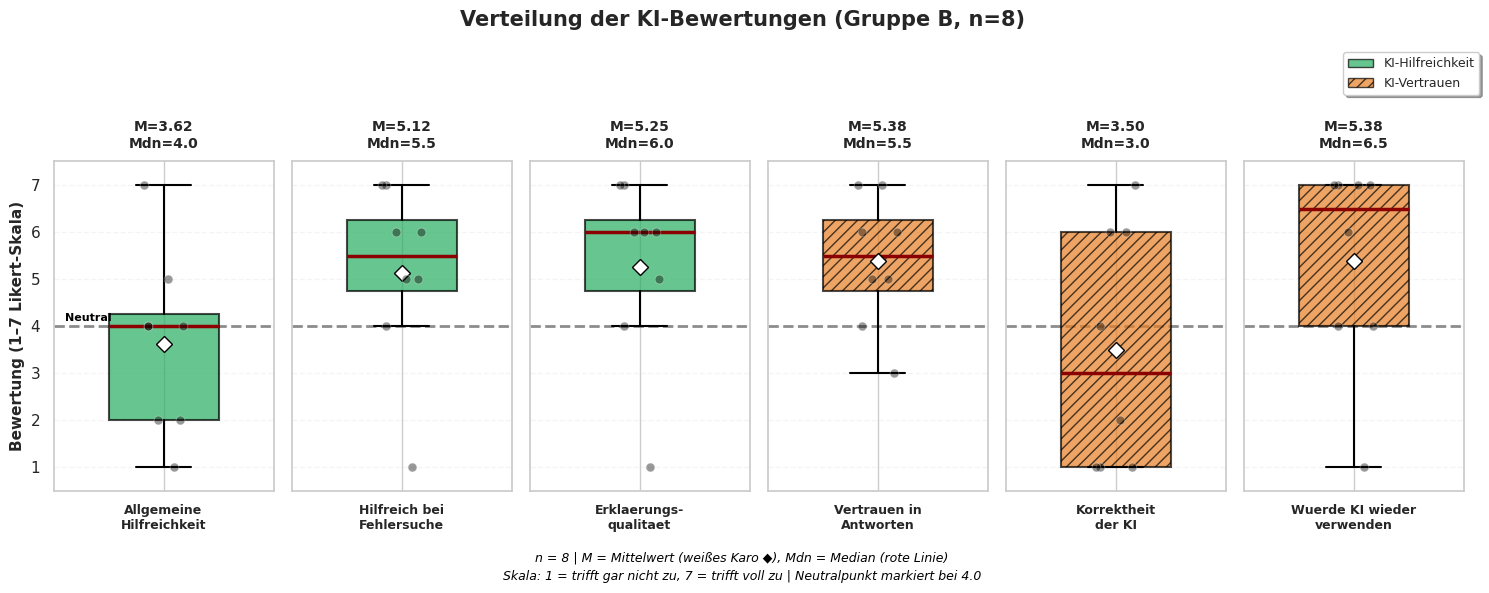

✅ Modernisierter Boxplot gespeichert: neu_boxplot_ki_items_distribution.png


In [79]:
# === GRAFIK 2b: KI-Items Verteilung (Modernisierter Boxplot) ===
if evals_b.empty or not available_items:
    print('⚠️ Keine Daten für Gruppe B vorhanden.')
else:
    # Subplots erstellen: Einer pro Item
    fig, axes = plt.subplots(1, len(available_items), figsize=(len(available_items) * 2.5, 6), sharey=True)
    if len(available_items) == 1:
        axes = [axes]

    # Kennwerte für die Legende sammeln
    legend_elements = [
        mpatches.Patch(facecolor='#27AE60', edgecolor='black', alpha=0.7, label='KI-Hilfreichkeit'),
        mpatches.Patch(facecolor='#E67E22', edgecolor='black', alpha=0.7, hatch='///', label='KI-Vertrauen')
    ]

    for i, (item, ax) in enumerate(zip(available_items, axes)):
        data_item = evals_b[item].dropna()
        m_val   = data_item.mean()
        mdn_val = data_item.median()
        
        # Kategorisierung für Farbe und Muster
        is_useful = 'useful' in item
        color = '#27AE60' if is_useful else '#E67E22'
        hatch = '' if is_useful else '///'

        # Boxplot mit weißem Diamanten (Mittelwert)
        bp = ax.boxplot(
            [data_item], positions=[0], widths=0.5, patch_artist=True,
            showmeans=True, 
            showfliers=False,
            meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='white', markersize=8),
            boxprops=dict(facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.7, hatch=hatch),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='darkred', linewidth=2.5),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.5)
        )

        # Jitter-Punkte für die Rohdaten
        np.random.seed(42)
        jitter = np.random.uniform(-0.1, 0.1, size=len(data_item))
        ax.scatter(jitter, data_item, color='black', edgecolors='white',
                   linewidths=0.5, s=40, alpha=0.4, zorder=3)

        # Neutralitätslinie (4.0) über den gesamten Hintergrund
        ax.axhline(4, color='gray', linestyle='--', alpha=0.9, linewidth=2.0, zorder=1)

        # Achsen-Beschriftung
        ax.set_xticks([0])
        ax.set_xticklabels([ITEM_LABELS.get(item, item)], fontsize=9, fontweight='bold')
        ax.set_ylim(0.5, 7.5)
        ax.set_yticks(range(1, 8))
        
        # Individueller Titel pro Box mit M und Mdn
        ax.set_title(f'M={m_val:.2f}\nMdn={mdn_val:.1f}', fontsize=10, fontweight='bold', pad=10)
        
        ax.yaxis.grid(True, alpha=0.2, linestyle='--')
        ax.set_axisbelow(True)
        
        if i == 0:
            ax.set_ylabel('Bewertung (1–7 Likert-Skala)', fontsize=11, fontweight='bold')
            # Label für die Neutrallinie nur im ersten Plot
            ax.text(-0.45, 4.1, 'Neutral', color='black', fontsize=8, fontweight='bold')

    # Übergreifender Titel
    fig.suptitle(f'Verteilung der KI-Bewertungen (Gruppe B, n={len(evals_b)})',
                 fontsize=15, fontweight='bold', y=0.90)

    # Legende oben rechts
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.1, 1.35), 
              fontsize=9, frameon=True, shadow=True)

    # Best-Practice Fußnote
    footer = (
        f'n = {len(evals_b)} | M = Mittelwert (weißes Karo ◆), Mdn = Median (rote Linie)\n'
        'Skala: 1 = trifft gar nicht zu, 7 = trifft voll zu | Neutralpunkt markiert bei 4.0'
    )
    add_footer(fig, footer, y=-0.05)

    plt.tight_layout()
    out_path = OUT_DIR / 'neu_boxplot_ki_items_distribution.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'✅ Modernisierter Boxplot gespeichert: {out_path.name}')

In [80]:
# === ANALYSE 4: DRILL-VIELFALT ===
drill_diversity = pd.DataFrame()
drill_top = pd.DataFrame()

if not drills.empty:
    drill_rows = []
    for _, row in drills.iterrows():
        group = str(row.get('group', ''))
        pid   = str(row.get('participant_id', ''))
        ids   = []

        mcq = str(row.get('mcq_drill_id', '')).strip()
        if mcq and mcq != 'nan':
            ids.append(mcq)

        code = str(row.get('code_drill_id', '')).strip()
        if code and code != 'nan':
            ids.append(code)

        selected = str(row.get('selected_drill_ids', '')).strip()
        if selected and selected != 'nan':
            ids.extend([x.strip() for x in selected.split('|') if x.strip()])

        for drill_id in ids:
            drill_rows.append({'participant_id': pid, 'group': group, 'drill_id': drill_id})

    drill_ids_df = pd.DataFrame(drill_rows)

    if not drill_ids_df.empty:
        # Häufigkeiten pro Drill
        drill_top = (
            drill_ids_df.groupby(['group', 'drill_id'])
            .size().reset_index(name='count')
            .sort_values(['group', 'count'], ascending=[True, False])
        )

        # Shannon-Entropie pro Gruppe
        def shannon(g):
            p = g['count'].values / g['count'].sum()
            return float(-(p * np.log(p + 1e-12)).sum())

        diversity_rows = []
        for group, g in drill_top.groupby('group'):
            n_unique = g['drill_id'].nunique()
            n_total  = g['count'].sum()
            entropy  = shannon(g)
            diversity_rows.append({
                'group': group,
                'unique_drills': n_unique,
                'total_drill_events': n_total,
                'shannon_entropy': entropy
            })

        drill_diversity = pd.DataFrame(diversity_rows)
        drill_diversity.to_csv(OUT_DIR / 'neu_drill_diversity.csv', index=False)
        drill_top.to_csv(OUT_DIR / 'neu_drill_top_by_group.csv', index=False)
        print('📊 Drill-Statistiken:')
        print(drill_diversity.to_string(index=False))
        print(f'\n   Top-Drills gesamt: {len(drill_top)} Einträge')
else:
    print('⚠️  Keine Drill-Daten verfügbar.')

📊 Drill-Statistiken:
group  unique_drills  total_drill_events  shannon_entropy
    A             97                 416         4.404154
    B             62                 226         3.845476

   Top-Drills gesamt: 159 Einträge


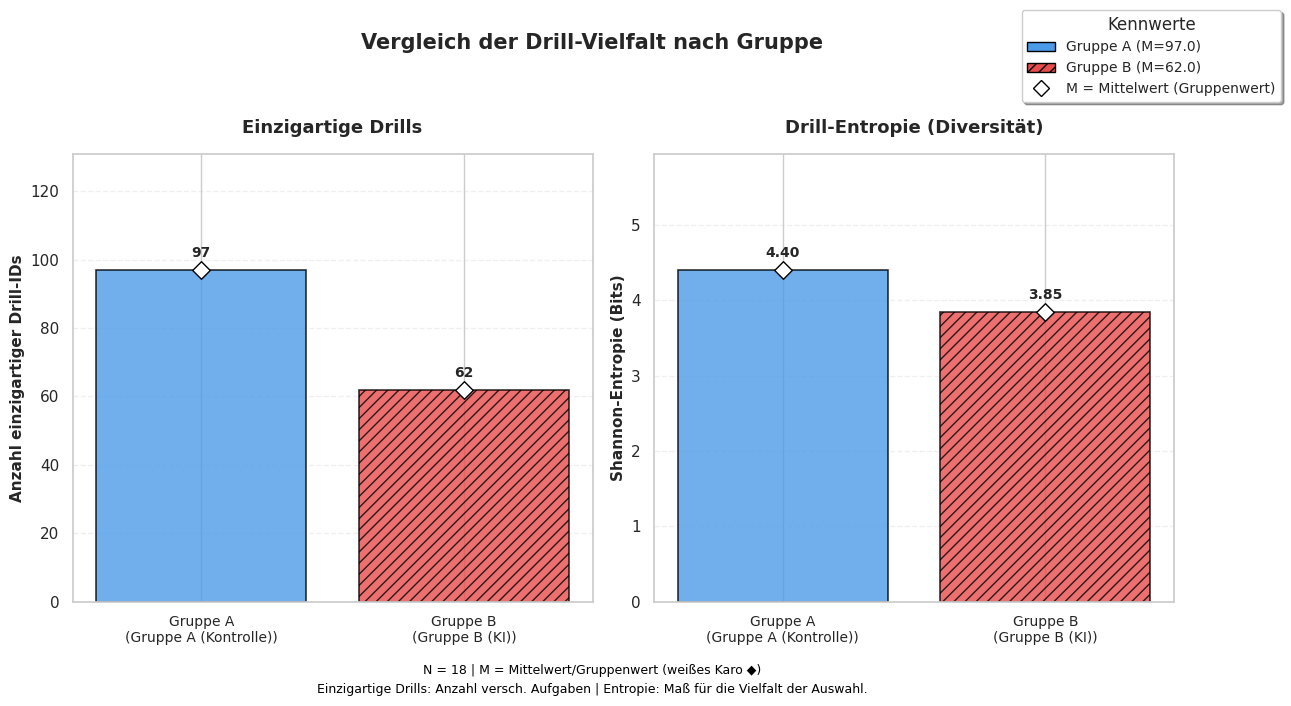

✅ Gespeichert: neu_drill_diversity_comparison.png


<Figure size 640x480 with 0 Axes>

In [81]:
# === GRAFIK 4: Drill-Vielfalt (Best-Practice-Edition mit Line2D Fix) ===
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

if drill_diversity.empty:
    print('⚠️ Keine Daten vorhanden.')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    for ax, metric, ylabel, title_suffix in [
        (ax1, 'unique_drills', 'Anzahl einzigartiger Drill-IDs', 'Einzigartige Drills'),
        (ax2, 'shannon_entropy', 'Shannon-Entropie (Bits)', 'Drill-Entropie (Diversität)'),
    ]:
        groups = drill_diversity['group'].tolist()
        values = drill_diversity[metric].tolist()
        x_pos  = range(len(groups))
        
        for i, (g, val) in enumerate(zip(groups, values)):
            # Balken mit deinen Gruppenfarben und Schraffuren
            ax.bar(i, val, color=GROUP_COLORS.get(g, 'gray'), edgecolor='black',
                   linewidth=1.2, hatch=GROUP_HATCH.get(g, ''), alpha=0.8)
            
            # Best Practice: Mittelwert-Symbol (M) auf Balkenhöhe [cite: 2026-03-07]
            ax.scatter(i, val, marker='D', color='white', edgecolors='black', 
                       s=80, zorder=5) 

            # Datenlabel über dem Balken
            ax.text(i, val + max(values)*0.03,
                    f'{val:.2f}' if isinstance(val, float) else str(val),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

        # Design-Finishing pro Subplot
        ax.set_xticks(list(x_pos))
        ax.set_xticklabels([f'Gruppe {g}\n({GROUP_LABELS[g]})' for g in groups], fontsize=10)
        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
        ax.set_title(title_suffix, fontsize=13, fontweight='bold', pad=15)
        ax.set_ylim(0, max(values) * 1.35) # Puffer für Legende/Labels
        ax.yaxis.grid(True, alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)

    fig.suptitle('Vergleich der Drill-Vielfalt nach Gruppe', fontsize=15, fontweight='bold', y=1.05)

    # Best Practice Legende mit Line2D [cite: 2026-03-07]
    # Hier ziehen wir die echten Werte für die Legendenbeschriftung
    m_a = drill_diversity.loc[drill_diversity["group"]=="A", "unique_drills"].values[0]
    m_b = drill_diversity.loc[drill_diversity["group"]=="B", "unique_drills"].values[0]

    legend_elements = [
        mpatches.Patch(facecolor=GROUP_COLORS['A'], edgecolor='black', label=f'Gruppe A (M={m_a:.1f})'),
        mpatches.Patch(facecolor=GROUP_COLORS['B'], edgecolor='black', hatch=GROUP_HATCH['B'], label=f'Gruppe B (M={m_b:.1f})'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='white', 
               markeredgecolor='black', markersize=8, label='M = Mittelwert (Gruppenwert)', linestyle='None')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.08, 1.10), 
               fontsize=10, shadow=True, title="Kennwerte")

    # Gestraffte Fußnote [cite: 2026-03-07]
    footer = (
        f"N = {len(participants)} | M = Mittelwert/Gruppenwert (weißes Karo ◆)\n"
        "Einzigartige Drills: Anzahl versch. Aufgaben | Entropie: Maß für die Vielfalt der Auswahl."
    )
    fig.text(0.5, -0.05, footer, ha='center', fontsize=9, color='black', linespacing=1.6)

    plt.tight_layout()
    plt.show()
    
    # save
    out_path = OUT_DIR / 'neu_drill_diversity_comparison.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f'✅ Gespeichert: {out_path.name}')

In [82]:
# === ANALYSE 5: KI-ANFRAGEN PRO STEP (Gruppe B) ===
chat_per_step_b = pd.DataFrame()

if not chat.empty and 'is_user' in chat.columns and not task_level.empty:
    user_chat_b = chat[(chat['is_user'] == 1) & (chat['group'] == 'B')].copy()
    user_chat_b['participant_id'] = user_chat_b['participant_id'].astype(str)

    # Step-Fenster aus task_level (Gruppe B, BMI-Kurs)
    bmi_steps_b = task_level[
        (task_level['group'] == 'B') &
        (task_level['course_id'] == 'bmi-calculator')
    ][['participant_id','step_number','step_started_at','step_completed_at']].copy()
    bmi_steps_b['participant_id'] = bmi_steps_b['participant_id'].astype(str)
    bmi_steps_b = bmi_steps_b.sort_values(['participant_id','step_number'])

    mapped = []
    for pid, group_chat in user_chat_b.groupby('participant_id'):
        wins = bmi_steps_b[bmi_steps_b['participant_id'] == pid]
        if wins.empty:
            continue
        for _, msg in group_chat.iterrows():
            ts = msg['timestamp']
            if pd.isna(ts):
                continue
            # Suche nach passendem Step-Fenster
            in_win = wins[
                wins['step_started_at'].notna() &
                wins['step_completed_at'].notna() &
                (wins['step_started_at'] <= ts) &
                (wins['step_completed_at'] >= ts)
            ]
            if not in_win.empty:
                step_row = in_win.iloc[0]
            else:
                # Fallback: letzter Step der vor dem Timestamp gestartet hat
                before = wins[
                    wins['step_started_at'].notna() &
                    (wins['step_started_at'] <= ts)
                ]
                if before.empty:
                    continue
                step_row = before.iloc[-1]

            mapped.append({'participant_id': pid, 'step_number': int(step_row['step_number'])})

    if mapped:
        mapped_df = pd.DataFrame(mapped)
        # Gesamtanzahl Nachrichten pro Step
        total_per_step = (
            mapped_df.groupby('step_number').size().reset_index(name='total_chat_msgs')
        )
        # Anzahl Teilnehmer pro Step (für Ø-Berechnung)
        n_participants_b = (task_level[
            (task_level['group'] == 'B') &
            (task_level['course_id'] == 'bmi-calculator')
        ].groupby('step_number')['participant_id'].nunique().reset_index(name='n_participants'))

        chat_per_step_b = total_per_step.merge(n_participants_b, on='step_number', how='left')
        chat_per_step_b['avg_chat_per_participant'] = (
            chat_per_step_b['total_chat_msgs'] / chat_per_step_b['n_participants']
        )
        # Nur Steps 1–12
        chat_per_step_b = chat_per_step_b[
            (chat_per_step_b['step_number'] >= 1) &
            (chat_per_step_b['step_number'] <= 12)
        ].sort_values('step_number')

        chat_per_step_b.to_csv(OUT_DIR / 'neu_chat_per_step_gruppe_b.csv', index=False)
        print('📊 Chat-Nachrichten pro Step (Gruppe B):')
        print(chat_per_step_b.to_string(index=False))
else:
    print('⚠️  Keine Chat- oder Task-Level-Daten für Step-Analyse.')

📊 Chat-Nachrichten pro Step (Gruppe B):
 step_number  total_chat_msgs  n_participants  avg_chat_per_participant
           1                1               9                  0.111111
           2                5               9                  0.555556
           3                2               9                  0.222222
           4                3               9                  0.333333
           5               10               9                  1.111111
           6                6               9                  0.666667
           8                5               9                  0.555556
           9                2               9                  0.222222
          11                2               8                  0.250000
          12                9               8                  1.125000


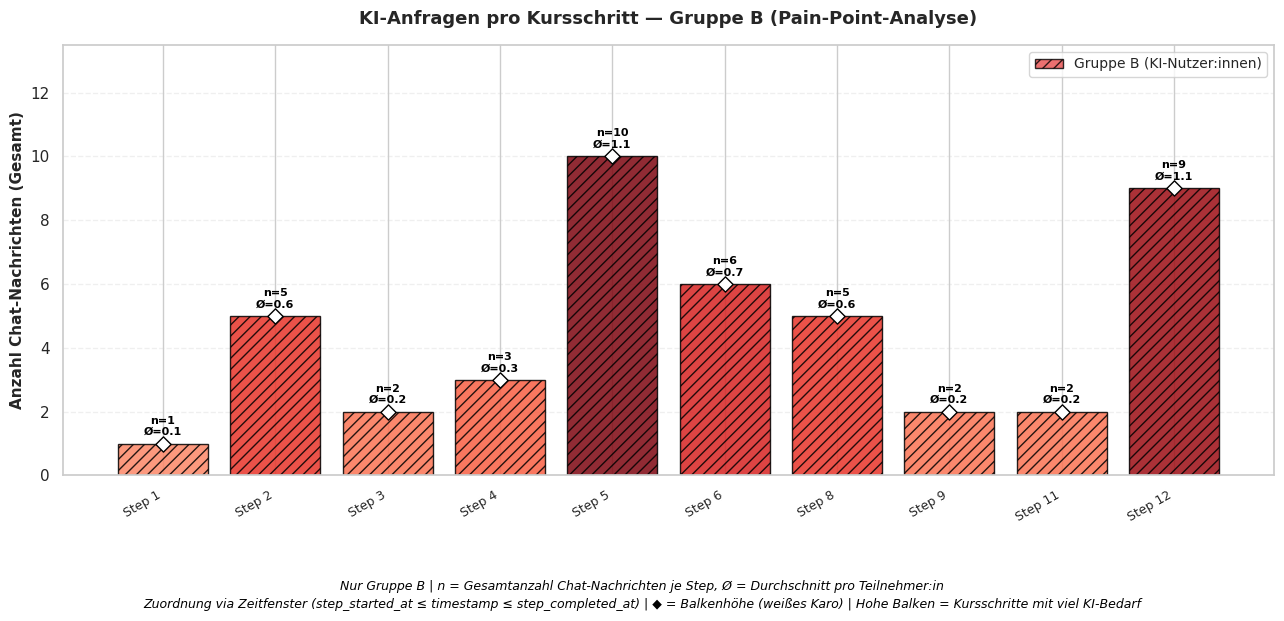

✅ Gespeichert: neu_barplot_chat_per_step_gruppe_b.png


In [83]:
# === GRAFIK 5: KI-Anfragen pro Step (Pain-Point-Analyse, Gruppe B) ===
if chat_per_step_b.empty:
    print('⚠️  Keine Daten.')
else:
    steps = chat_per_step_b['step_number'].values
    total_vals = chat_per_step_b['total_chat_msgs'].values
    avg_vals   = chat_per_step_b['avg_chat_per_participant'].values

    # Schrittweise Farben (Intensität nach Anzahl)
    norm_max = max(total_vals) if total_vals.max() > 0 else 1
    step_colors = [
        plt.cm.Reds(0.35 + 0.6 * (v / norm_max)) for v in total_vals
    ]

    fig, ax = plt.subplots(figsize=(13, 5.5))

    x_pos = np.arange(len(steps))
    bars = ax.bar(x_pos, total_vals, color=step_colors,
                  edgecolor='black', linewidth=1.0,
                  hatch=GROUP_HATCH['B'], alpha=0.85)

    # Wert (Gesamt + Ø) direkt über jedem Balken
    for bar, total, avg in zip(bars, total_vals, avg_vals):
        offset = max(total_vals) * 0.02
        ax.text(
            bar.get_x() + bar.get_width()/2,
            total + offset,
            f'n={total}\nØ={avg:.1f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold', color='black'
        )

    # Weißes Karo auf Balkenhöhe
    ax.scatter(x_pos, total_vals,
               marker='D', color='white', edgecolors='black', s=60, zorder=5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'Step {s}' for s in steps], fontsize=9, rotation=30, ha='right')
    ax.set_ylabel('Anzahl Chat-Nachrichten (Gesamt)', fontsize=11, fontweight='bold')
    ax.set_title(
        'KI-Anfragen pro Kursschritt — Gruppe B (Pain-Point-Analyse)',
        fontsize=13, fontweight='bold', pad=15
    )

    # Legendenpatch
    red_patch = mpatches.Patch(
        facecolor=GROUP_COLORS['B'], edgecolor='black',
        hatch=GROUP_HATCH['B'], alpha=0.8,
        label='Gruppe B (KI-Nutzer:innen)'
    )
    ax.legend(handles=[red_patch], loc='upper right', fontsize=10)

    ax.yaxis.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(0, max(total_vals) * 1.35 if len(total_vals) > 0 else 10)

    n_b_chat = chat_per_step_b['n_participants'].max() if 'n_participants' in chat_per_step_b.columns else '?'
    footer = (
        f'Nur Gruppe B | n = Gesamtanzahl Chat-Nachrichten je Step, Ø = Durchschnitt pro Teilnehmer:in\n'
        f'Zuordnung via Zeitfenster (step_started_at ≤ timestamp ≤ step_completed_at) | '
        f'◆ = Balkenhöhe (weißes Karo) | Hohe Balken = Kursschritte mit viel KI-Bedarf'
    )
    add_footer(fig, footer, y=-0.12)

    plt.tight_layout()
    out_path = OUT_DIR / 'neu_barplot_chat_per_step_gruppe_b.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'✅ Gespeichert: {out_path.name}')

In [84]:
# === ANALYSE 6: DRILL-SCHWIERIGKEIT (Attempts to Solve) ===

attempt_dist = pd.DataFrame()

if not events.empty:
    # Nur Drill-relevante Events filtern
    drill_events = events[events['event_type'].str.contains('drill', case=False, na=False)].copy()
    drill_events['success'] = pd.to_numeric(drill_events['success'], errors='coerce').fillna(0)
    drill_events = drill_events.sort_values(['participant_id', 'timestamp'])

    results = []
    
    for pid, grp in drill_events.groupby('participant_id'):
        group_val = grp['group'].iloc[0]
        
        mcq_attempts = 0
        code_attempts = 0
        mcq_solved = False
        code_solved = False
        
        for _, row in grp.iterrows():
            etype = row['event_type']
            
            if etype == 'drill_mcq_completed':
                if not mcq_solved: # Zählen bis zur ersten Lösung
                    mcq_attempts += 1
                    if row['success'] == 1:
                        results.append({'participant_id': pid, 'group': group_val, 'drill_type': 'MCQ', 
                                        'attempts': mcq_attempts, 'solved': True})
                        mcq_solved = True
                        
            elif etype == 'drill_code_completed':
                if not code_solved:
                    code_attempts += 1
                    if row['success'] == 1:
                        results.append({'participant_id': pid, 'group': group_val, 'drill_type': 'Code', 
                                        'attempts': code_attempts, 'solved': True})
                        code_solved = True
                        
            elif etype == 'drill_session_completed':
                # Ungelöste Drills aufzeichnen falls die Session abgebrochen wurde (optional)
                if mcq_attempts > 0 and not mcq_solved:
                    results.append({'participant_id': pid, 'group': group_val, 'drill_type': 'MCQ', 
                                    'attempts': mcq_attempts, 'solved': False})
                if code_attempts > 0 and not code_solved:
                    results.append({'participant_id': pid, 'group': group_val, 'drill_type': 'Code', 
                                    'attempts': code_attempts, 'solved': False})
                    
                # Reset für die nächste Drill-Session
                mcq_attempts = 0
                code_attempts = 0
                mcq_solved = False
                code_solved = False

    sessions_df = pd.DataFrame(results)

    if not sessions_df.empty:
        # Nur gelöste Drills betrachten
        solved_df = sessions_df[sessions_df['solved'] == True].copy()

        def bin_attempts(n):
            if n == 1: return '1. Versuch'
            if n == 2: return '2. Versuch'
            if n == 3: return '3. Versuch'
            return '4+ Versuche'

        solved_df['attempt_bin'] = solved_df['attempts'].apply(bin_attempts)
        bin_order = ['1. Versuch', '2. Versuch', '3. Versuch', '4+ Versuche']

        attempt_dist = (
            solved_df.groupby(['group', 'attempt_bin'])
            .size().reset_index(name='count')
        )
        
        # Prozentanteile innerhalb der Gruppe
        totals = attempt_dist.groupby('group')['count'].transform('sum')
        attempt_dist['pct'] = (attempt_dist['count'] / totals * 100).round(1)

        attempt_dist.to_csv(OUT_DIR / 'neu_drill_attempts_distribution.csv', index=False)
        solved_df.to_csv(OUT_DIR / 'neu_drill_attempts_details.csv', index=False)
        
        print('📊 Drill-Schwierigkeit (Attempts-to-Solve Distribution):')
        print(attempt_dist.to_string(index=False))
        print(f'\n   Erfasste Drill-Tasks (MCQ/Code): {len(sessions_df)}')
        print(f'   Davon gelöst: {len(solved_df)}')
else:
    print('⚠️  Keine Event-Timeline-Daten verfügbar.')

📊 Drill-Schwierigkeit (Attempts-to-Solve Distribution):
group attempt_bin  count  pct
    A  1. Versuch    178 86.0
    A  2. Versuch     20  9.7
    A  3. Versuch      4  1.9
    A 4+ Versuche      5  2.4
    B  1. Versuch    189 83.6
    B  2. Versuch     19  8.4
    B  3. Versuch      5  2.2
    B 4+ Versuche     13  5.8

   Erfasste Drill-Tasks (MCQ/Code): 433
   Davon gelöst: 433


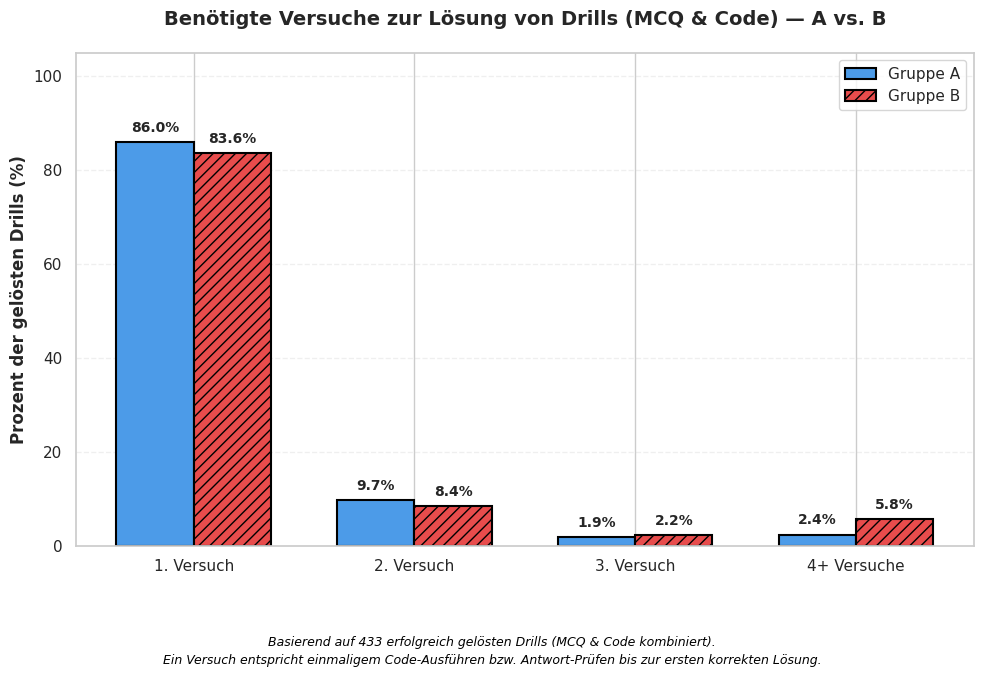

✅ Gespeichert: neu_barplot_drill_attempts_difficulty.png


In [85]:
# === GRAFIK 6: Drill-Schwierigkeit (Gruppenvergleich) ===
if attempt_dist.empty:
    print('⚠️  Keine Daten – Grafik wird übersprungen.')
else:
    # Balkendiagramm: Gruppe A und B nebeneinander für jedes Attempt-Bin
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bin_order = ['1. Versuch', '2. Versuch', '3. Versuch', '4+ Versuche']
    groups = ['A', 'B']
    x_pos = np.arange(len(bin_order))
    width = 0.35

    for i, g in enumerate(groups):
        g_data = attempt_dist[attempt_dist['group'] == g].set_index('attempt_bin')
        # Auffüllen fehlender Kategorien mit 0
        vals = [g_data.loc[b, 'pct'] if b in g_data.index else 0 for b in bin_order]
        
        offset = (i - 0.5) * width
        bars = ax.bar(
            x_pos + offset, vals, width,
            color=GROUP_COLORS.get(g, 'gray'),
            edgecolor='black', linewidth=1.5,
            hatch=GROUP_HATCH.get(g, ''),
            label=f'Gruppe {g}'
        )
        
        # Werte über den Balken
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    val + 1.5,
                    f'{val:.1f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold'
                )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(bin_order, fontsize=11)
    ax.set_ylabel('Prozent der gelösten Drills (%)', fontsize=12, fontweight='bold')
    ax.set_title('Benötigte Versuche zur Lösung von Drills (MCQ & Code) — A vs. B', fontsize=14, fontweight='bold', pad=20)
    
    ax.legend(fontsize=11, loc='upper right')
    ax.yaxis.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(0, 105)

    footer = (
        f'Basierend auf {len(solved_df)} erfolgreich gelösten Drills (MCQ & Code kombiniert).\n'
        f'Ein Versuch entspricht einmaligem Code-Ausführen bzw. Antwort-Prüfen bis zur ersten korrekten Lösung.'
    )
    add_footer(fig, footer, y=-0.12)

    plt.tight_layout()
    out_path = OUT_DIR / 'neu_barplot_drill_attempts_difficulty.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'✅ Gespeichert: {out_path.name}')

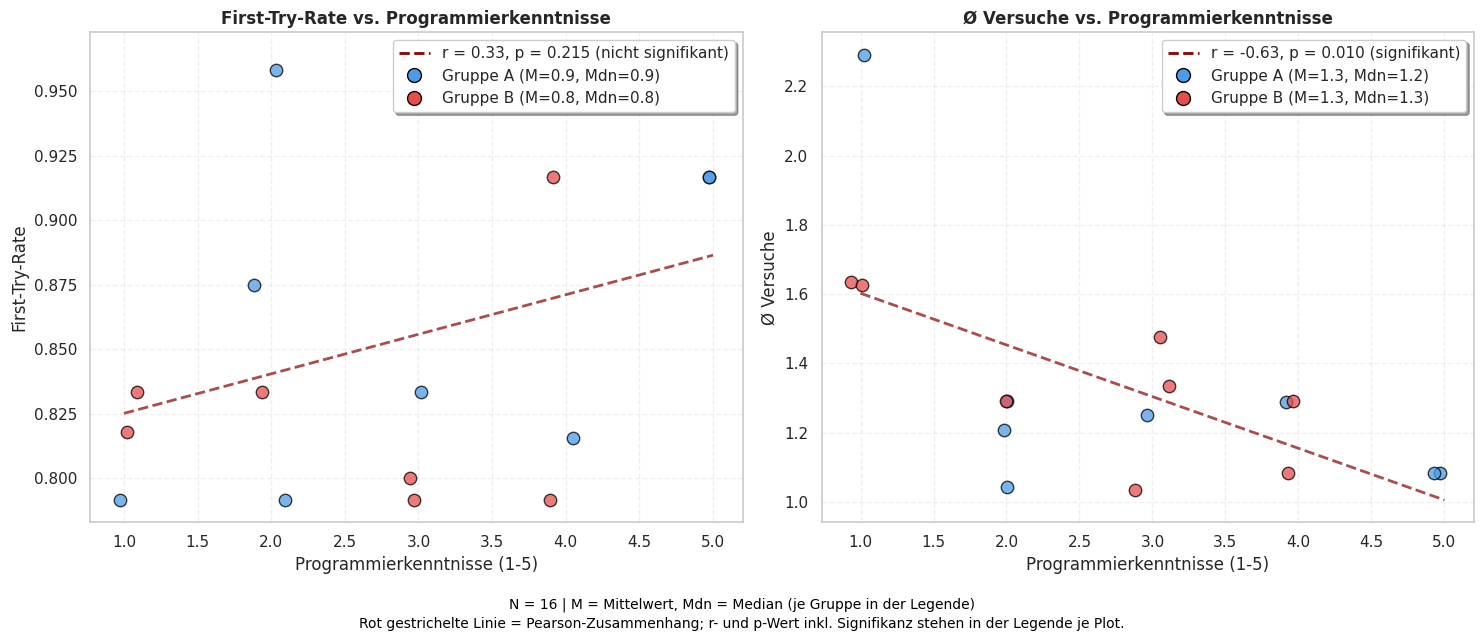

✅ Gespeichert: performance_drill_korrelation_clean.png


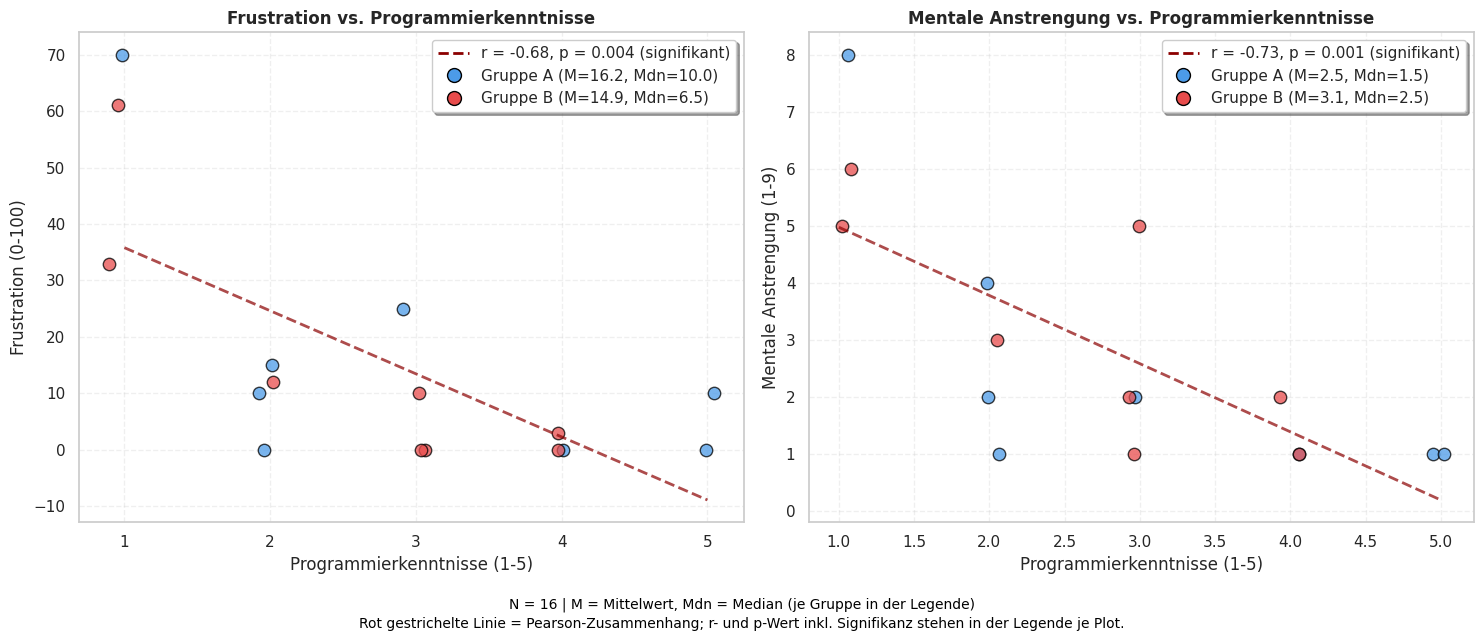

✅ Gespeichert: korrelation_tlx_vergleich.png


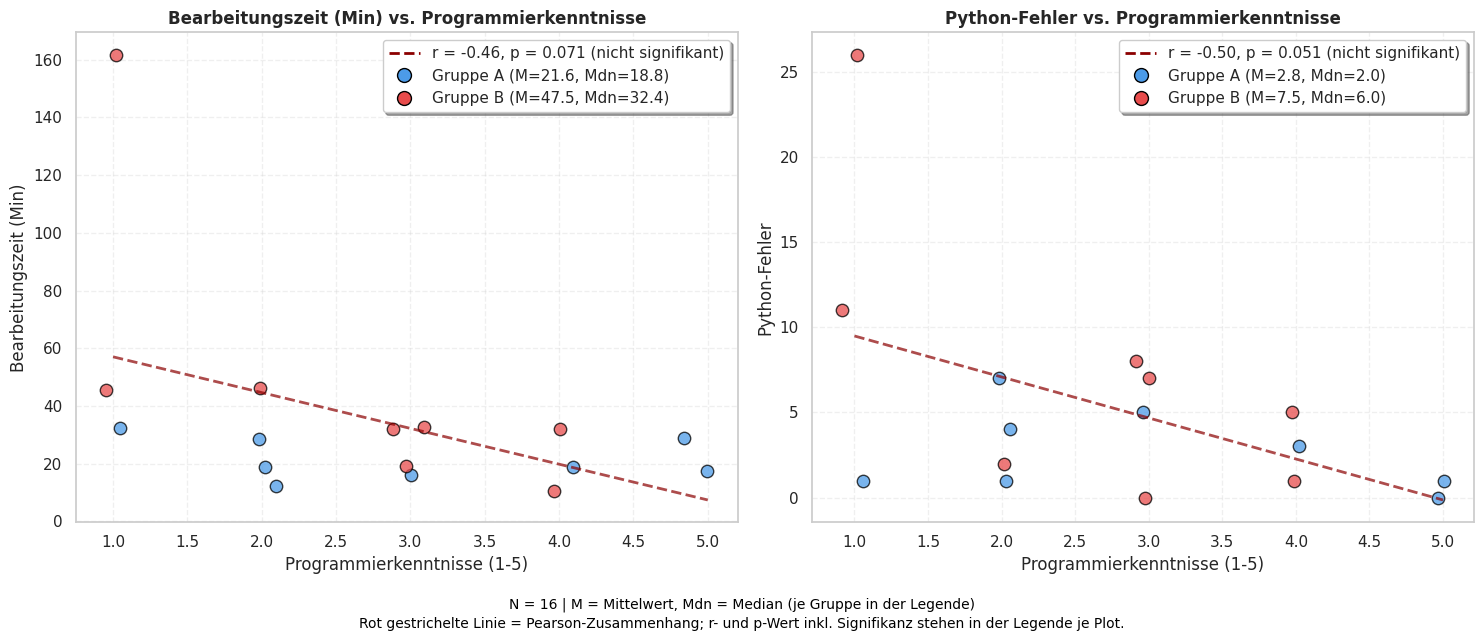

✅ Gespeichert: korrelation_performance_vergleich.png


In [86]:
# === Standalone Korrelationen (robust) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

GROUP_COLORS_LOCAL = {"A": "#4C9BE8", "B": "#E84C4C"}


def corr_label(r_val: float, p_val: float) -> str:
    sig = "signifikant" if p_val < 0.05 else "nicht signifikant"
    return f"r = {r_val:.2f}, p = {p_val:.3f} ({sig})"


def legend_handles_for_corr(df: pd.DataFrame, ycol: str, r_val: float, p_val: float):
    handles = [
        Line2D([0], [0], color="darkred", linestyle="--", linewidth=2,
               label=corr_label(r_val, p_val))
    ]

    for g in ["A", "B"]:
        gdf = df[df["group"] == g]
        if gdf.empty:
            continue
        m_val = gdf[ycol].mean()
        mdn_val = gdf[ycol].median()
        handles.append(
            Line2D(
                [0], [0], marker="o", linestyle="None", markersize=10,
                markerfacecolor=GROUP_COLORS_LOCAL.get(g, "gray"),
                markeredgecolor="black",
                label=f"Gruppe {g} (M={m_val:.1f}, Mdn={mdn_val:.1f})"
            )
        )
    return handles


# Spalten harmonisieren (camelCase -> snake_case), damit dropna/Plots stabil laufen
if "evals" in globals() and not evals.empty:
    evals_norm = evals.copy()
    rename_map = {}
    if "programmingKnowledge" in evals_norm.columns and "programming_knowledge" not in evals_norm.columns:
        rename_map["programmingKnowledge"] = "programming_knowledge"
    if "mentalEffort" in evals_norm.columns and "mental_effort" not in evals_norm.columns:
        rename_map["mentalEffort"] = "mental_effort"
    if "npsScore" in evals_norm.columns and "nps_score" not in evals_norm.columns:
        rename_map["npsScore"] = "nps_score"
    if rename_map:
        evals_norm = evals_norm.rename(columns=rename_map)
else:
    evals_norm = pd.DataFrame()

# 1) Drill-Performance vs Programmierkenntnisse
if "attempt_dist" in globals() and not attempt_dist.empty and "participants" in globals():
    # Details rekonstruiert aus solved_df, falls vorhanden
    if "solved_df" in globals() and not solved_df.empty and not evals_norm.empty:
        perf = solved_df.groupby(["participant_id", "group"]).agg(
            first_try_rate=("attempts", lambda x: (x == 1).mean()),
            mean_attempts=("attempts", "mean")
        ).reset_index()

        eval_cols = [c for c in ["participant_id", "programming_knowledge"] if c in evals_norm.columns]
        if len(eval_cols) == 2:
            eval_pk = evals_norm[eval_cols].copy()
            eval_pk["participant_id"] = eval_pk["participant_id"].astype(str)
            perf["participant_id"] = perf["participant_id"].astype(str)

            merged_perf = perf.merge(eval_pk, on="participant_id", how="inner")
            merged_perf["programming_knowledge"] = pd.to_numeric(merged_perf["programming_knowledge"], errors="coerce")
            merged_perf = merged_perf.dropna(subset=["programming_knowledge", "first_try_rate", "mean_attempts"])

            if len(merged_perf) >= 3:
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                metrics = [("first_try_rate", "First-Try-Rate"), ("mean_attempts", "Ø Versuche")]

                for ax, (ycol, ylab) in zip(axes, metrics):
                    for g in ["A", "B"]:
                        gdf = merged_perf[merged_perf["group"] == g]
                        if gdf.empty:
                            continue
                        jitter = np.random.normal(0, 0.06, size=len(gdf))
                        ax.scatter(
                            gdf["programming_knowledge"] + jitter,
                            gdf[ycol],
                            color=GROUP_COLORS_LOCAL.get(g, "gray"),
                            edgecolors="black",
                            alpha=0.75,
                            s=80
                        )

                    r, p = pearsonr(merged_perf["programming_knowledge"], merged_perf[ycol])
                    m, b = np.polyfit(merged_perf["programming_knowledge"], merged_perf[ycol], 1)
                    xs = np.linspace(1, 5, 100)
                    ax.plot(xs, m * xs + b, "--", color="darkred", alpha=0.7, linewidth=2)

                    ax.set_title(f"{ylab} vs. Programmierkenntnisse", fontweight="bold")
                    ax.set_xlabel("Programmierkenntnisse (1-5)")
                    ax.set_ylabel(ylab)
                    ax.grid(alpha=0.3, linestyle="--")

                    handles = legend_handles_for_corr(merged_perf, ycol, r, p)
                    ax.legend(handles=handles, loc="upper right", frameon=True, shadow=True)

                footer = (
                    f"N = {len(merged_perf)} | M = Mittelwert, Mdn = Median (je Gruppe in der Legende)\n"
                    "Rot gestrichelte Linie = Pearson-Zusammenhang; r- und p-Wert inkl. Signifikanz stehen in der Legende je Plot."
                )
                fig.text(0.5, -0.06, footer, ha="center", fontsize=10, color="black", linespacing=1.5)

                plt.tight_layout()
                plt.savefig(OUT_DIR / "performance_drill_korrelation_clean.png", dpi=300, bbox_inches="tight")
                plt.show()
                print("✅ Gespeichert: performance_drill_korrelation_clean.png")

# 2) TLX-Korrelation + Performance-Korrelation
if "participants" in globals() and not participants.empty and not evals_norm.empty:
    # gemeinsame Basis
    pcols = [c for c in ["participant_id", "group", "bmi_time_minutes", "bmi_python_errors"] if c in participants.columns]
    ecols = [c for c in ["participant_id", "programming_knowledge", "frustration", "mental_effort"] if c in evals_norm.columns]

    if len(pcols) >= 3 and len(ecols) >= 2:
        pdf = participants[pcols].copy()
        edf = evals_norm[ecols].copy()
        pdf["participant_id"] = pdf["participant_id"].astype(str)
        edf["participant_id"] = edf["participant_id"].astype(str)

        merged = pdf.merge(edf, on="participant_id", how="inner", suffixes=("", "_eval"))
        if "group_eval" in merged.columns:
            merged["group"] = merged["group"].fillna(merged["group_eval"])

        for c in ["programming_knowledge", "frustration", "mental_effort", "bmi_time_minutes", "bmi_python_errors"]:
            if c in merged.columns:
                merged[c] = pd.to_numeric(merged[c], errors="coerce")

        # Skalen-Validierung: frustration 0-100, mental_effort 1-9
        if "frustration" in merged.columns:
            merged.loc[~merged["frustration"].between(0, 100), "frustration"] = np.nan
        if "mental_effort" in merged.columns:
            merged.loc[~merged["mental_effort"].between(1, 9), "mental_effort"] = np.nan

        # TLX Vergleich
        tlx_need = [c for c in ["programming_knowledge", "frustration", "mental_effort"] if c in merged.columns]
        if len(tlx_need) == 3:
            mt = merged.dropna(subset=tlx_need).copy()
            if len(mt) >= 3:
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                for ax, ycol, ylab in [(axes[0], "frustration", "Frustration"), (axes[1], "mental_effort", "Mentale Anstrengung")]:
                    for g in ["A", "B"]:
                        gdf = mt[mt["group"] == g]
                        if gdf.empty:
                            continue
                        jitter = np.random.normal(0, 0.06, size=len(gdf))
                        ax.scatter(
                            gdf["programming_knowledge"] + jitter,
                            gdf[ycol],
                            color=GROUP_COLORS_LOCAL.get(g, "gray"),
                            edgecolors="black",
                            alpha=0.75,
                            s=80
                        )

                    r, p = pearsonr(mt["programming_knowledge"], mt[ycol])
                    m, b = np.polyfit(mt["programming_knowledge"], mt[ycol], 1)
                    xs = np.linspace(1, 5, 100)
                    ax.plot(xs, m * xs + b, "--", color="darkred", alpha=0.7, linewidth=2)

                    ax.set_title(f"{ylab} vs. Programmierkenntnisse", fontweight="bold")
                    ax.set_xlabel("Programmierkenntnisse (1-5)")
                    ax.set_ylabel(f"{ylab} (1-9)" if ycol == "mental_effort" else f"{ylab} (0-100)")
                    ax.grid(alpha=0.3, linestyle="--")

                    handles = legend_handles_for_corr(mt, ycol, r, p)
                    ax.legend(handles=handles, loc="upper right", frameon=True, shadow=True)

                footer = (
                    f"N = {len(mt)} | M = Mittelwert, Mdn = Median (je Gruppe in der Legende)\n"
                    "Rot gestrichelte Linie = Pearson-Zusammenhang; r- und p-Wert inkl. Signifikanz stehen in der Legende je Plot."
                )
                fig.text(0.5, -0.06, footer, ha="center", fontsize=10, color="black", linespacing=1.5)

                plt.tight_layout()
                plt.savefig(OUT_DIR / "korrelation_tlx_vergleich.png", dpi=300, bbox_inches="tight")
                plt.show()
                print("✅ Gespeichert: korrelation_tlx_vergleich.png")

        # Performance Vergleich
        perf_need = [c for c in ["programming_knowledge", "bmi_time_minutes", "bmi_python_errors"] if c in merged.columns]
        if len(perf_need) == 3:
            mp = merged.dropna(subset=perf_need).copy()
            if len(mp) >= 3:
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                for ax, ycol, ylab in [(axes[0], "bmi_time_minutes", "Bearbeitungszeit (Min)"), (axes[1], "bmi_python_errors", "Python-Fehler")]:
                    for g in ["A", "B"]:
                        gdf = mp[mp["group"] == g]
                        if gdf.empty:
                            continue
                        jitter = np.random.normal(0, 0.06, size=len(gdf))
                        ax.scatter(
                            gdf["programming_knowledge"] + jitter,
                            gdf[ycol],
                            color=GROUP_COLORS_LOCAL.get(g, "gray"),
                            edgecolors="black",
                            alpha=0.75,
                            s=80
                        )

                    r, p = pearsonr(mp["programming_knowledge"], mp[ycol])
                    m, b = np.polyfit(mp["programming_knowledge"], mp[ycol], 1)
                    xs = np.linspace(1, 5, 100)
                    ax.plot(xs, m * xs + b, "--", color="darkred", alpha=0.7, linewidth=2)

                    ax.set_title(f"{ylab} vs. Programmierkenntnisse", fontweight="bold")
                    ax.set_xlabel("Programmierkenntnisse (1-5)")
                    ax.set_ylabel(ylab)
                    ax.grid(alpha=0.3, linestyle="--")

                    handles = legend_handles_for_corr(mp, ycol, r, p)
                    ax.legend(handles=handles, loc="upper right", frameon=True, shadow=True)

                footer = (
                    f"N = {len(mp)} | M = Mittelwert, Mdn = Median (je Gruppe in der Legende)\n"
                    "Rot gestrichelte Linie = Pearson-Zusammenhang; r- und p-Wert inkl. Signifikanz stehen in der Legende je Plot."
                )
                fig.text(0.5, -0.06, footer, ha="center", fontsize=10, color="black", linespacing=1.5)

                plt.tight_layout()
                plt.savefig(OUT_DIR / "korrelation_performance_vergleich.png", dpi=300, bbox_inches="tight")
                plt.show()
                print("✅ Gespeichert: korrelation_performance_vergleich.png")

In [87]:
# === Finales Mapping auf die Abgabe-Dateien + Manifest + README ===
import csv
import hashlib
import shutil
from datetime import datetime, timezone
from pathlib import Path

if "PROJECT_ROOT" not in globals():
    base = Path.cwd()
    candidates = [base, base.parent, base.parent.parent, base.parent.parent.parent]
    PROJECT_ROOT = None
    for c in candidates:
        if (c / "analysis" / "output").exists():
            PROJECT_ROOT = c
            break
    if PROJECT_ROOT is None:
        raise FileNotFoundError("analysis/output nicht gefunden")

OUT = PROJECT_ROOT / "analysis" / "output"
OUT.mkdir(parents=True, exist_ok=True)

# Neues, sprechendes Mapping (alt -> neu)
FILE_MAP = {
    "Drill_Diversity_Entropy_Comparison.png": ["barplot_drill_diversity.png", "Drill_Diversity_Entropy_Comparison.png"],
    "Performance_BMI_Python_Errors_Boxplot.png": ["boxplot_bmi_python_errors.png", "Performance_BMI_Python_Errors_Boxplot.png"],
    "Performance_BMI_Time_Comparison.png": ["boxplot_bmi_time_minutes.png", "Performance_BMI_Time_Comparison.png"],
    "Correlation_ChatIntensity_vs_PythonErrors_GrpB.png": ["chat_vs_errors_correlation_group_b.png", "Correlation_ChatIntensity_vs_PythonErrors_GrpB.png"],
    "Process_Errors_per_Step_Timeline.png": ["errors_per_step_by_group_labeled.png", "Process_Errors_per_Step_Timeline.png"],
    "AI_Usage_Total_Messages_GrpB.png": ["ki_usage_chat_sent_group_b.png", "AI_Usage_Total_Messages_GrpB.png"],
    "Correlation_Experience_vs_Time_and_Errors.png": ["korrelation_performance_vergleich.png", "Correlation_Experience_vs_Time_and_Errors.png"],
    "Correlation_Experience_vs_Frustration_and_Effort.png": ["korrelation_tlx_vergleich.png", "Correlation_Experience_vs_Frustration_and_Effort.png"],
    "AI_Usage_Messages_per_Step_GrpB.png": ["neu_barplot_chat_per_step_gruppe_b.png", "AI_Usage_Messages_per_Step_GrpB.png"],
    "Performance_Drill_Attempts_Comparison.png": ["neu_barplot_drill_attempts_difficulty.png", "Performance_Drill_Attempts_Comparison.png"],
    "Drill_Diversity_Unique_Tasks_Comparison.png": ["neu_barplot_drill_diversity.png", "neu_drill_diversity_comparison.png", "Drill_Diversity_Unique_Tasks_Comparison.png"],
    "AI_Evaluation_Items_Distribution_GrpB.png": ["neu_boxplot_ki_items_distribution.png", "AI_Evaluation_Items_Distribution_GrpB.png", "neu_boxplot_ki_items_distribution copy.png"],
    "Correlation_Experience_vs_Drill_Performance.png": ["performance_drill_korrelation_clean.png", "Correlation_Experience_vs_Drill_Performance.png"],
    "Demographics_Age_Distribution.png": ["q_eval_demographics_by_group.png", "Demographics_Age_Distribution.png"],
    "NASA_TLX_Frustration_Effort_Comparison.png": ["q_eval_nasa_tlx_by_group.png", "NASA_TLX_Frustration_Effort_Comparison.png"],
    "Demographics_Prior_Knowledge_Comparison.png": ["q_eval_programming_knowledge_by_group.png", "Demographics_Prior_Knowledge_Comparison.png"],
    "Evaluation_SUS_and_NPS_Comparison.png": ["q_eval_sus_nps_by_group.png", "Evaluation_SUS_and_NPS_Comparison.png"],
    "Evaluation_UEQS_Items_Profile.png": ["q_eval_ueqs_items_profile_1_to_7.png", "Evaluation_UEQS_Items_Profile.png"],
    "Process_Time_per_Step_Timeline.png": ["time_per_step_by_group_labeled.png", "Process_Time_per_Step_Timeline.png"]
}

SEARCH_DIRS = [
    OUT,
    OUT / "neu",
    OUT / "neu11",
    PROJECT_ROOT / "analysis",
    PROJECT_ROOT / "analysis" / "fragebogen",
    PROJECT_ROOT / "analysis" / "analysis" / "output" / "fragebogen",
    PROJECT_ROOT / "output" / "neu"
 ]

def find_latest(names):
    cand = []
    for d in SEARCH_DIRS:
        for n in names:
            p = d / n
            if p.exists():
                cand.append(p)
    if not cand:
        return None
    return sorted(cand, key=lambda x: x.stat().st_mtime)[-1]

def sha256_file(path):
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

rows = []
for final_name, aliases in FILE_MAP.items():
    src = find_latest(aliases)
    dst = OUT / final_name
    if src is None:
        rows.append({
            "entry_status": "missing",
            "source_path": "",
            "target_path": str(dst.relative_to(PROJECT_ROOT)),
            "filename": final_name,
            "size_bytes": "",
            "sha256": ""
        })
        continue

    same_file = src.resolve() == dst.resolve() if dst.exists() else False
    if not same_file:
        shutil.copy2(src, dst)

    rows.append({
        "entry_status": "included",
        "source_path": str(src.relative_to(PROJECT_ROOT)),
        "target_path": str(dst.relative_to(PROJECT_ROOT)),
        "filename": final_name,
        "size_bytes": dst.stat().st_size,
        "sha256": sha256_file(dst)
    })

# Alte Alias-PNGs im output-Root aufräumen, damit nur finale Namen bleiben
final_png_names = set(FILE_MAP.keys())
alias_png_names = set()
for aliases in FILE_MAP.values():
    for alias in aliases:
        if alias.lower().endswith('.png'):
            alias_png_names.add(alias)

deleted_aliases = []
for p in OUT.glob("*.png"):
    if p.name not in final_png_names and p.name in alias_png_names:
        p.unlink()
        deleted_aliases.append(p.name)

manifest = OUT / "manifest_final.csv"
with manifest.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["entry_status", "source_path", "target_path", "filename", "size_bytes", "sha256"]
    )
    writer.writeheader()
    writer.writerows(rows)

included = [r["filename"] for r in rows if r["entry_status"] == "included"]
ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
readme_lines = [
    "# Finaler Output (Bachelorarbeit)",
    "",
    f"Generiert am: {ts}",
    "",
    "Dieses Notebook erzeugt die finalen Abgabe-Grafiken eigenständig (ohne Notebook-Referenzausführung).",
    "",
    f"- Enthaltene PNGs: {len(included)}",
    "- Manifest: analysis/output/manifest_final.csv",
    "",
    "## Dateien",
    ""
 ]
for i, name in enumerate(included, 1):
    readme_lines.append(f"{i}. `{name}`")
(OUT / "README.md").write_text("\n".join(readme_lines) + "\n", encoding="utf-8")

print(f"✅ Included: {len(included)} / {len(FILE_MAP)}")
if deleted_aliases:
    print(f"🧹 Entfernte alte Alias-Dateien: {len(deleted_aliases)}")
missing = [r for r in rows if r["entry_status"] == "missing"]
if missing:
    print("⚠️ Missing:")
    for r in missing:
        print(" -", r["filename"])
else:
    print("✅ Keine fehlenden finalen Grafiken.")

✅ Included: 19 / 19
🧹 Entfernte alte Alias-Dateien: 15
✅ Keine fehlenden finalen Grafiken.


In [88]:
# === Quick Check ===
from pathlib import Path
base = Path.cwd()
cands = [base, base.parent, base.parent.parent, base.parent.parent.parent]
root = None
for c in cands:
    if (c / "analysis" / "output").exists():
        root = c
        break
out = root / "analysis" / "output"
pngs = sorted(out.glob("*.png"))
print(f"PNG in analysis/output: {len(pngs)}")
for i, p in enumerate(pngs, 1):
    print(f"{i:2d}. {p.name}")


PNG in analysis/output: 19
 1. AI_Evaluation_Items_Distribution_GrpB.png
 2. AI_Usage_Messages_per_Step_GrpB.png
 3. AI_Usage_Total_Messages_GrpB.png
 4. Correlation_ChatIntensity_vs_PythonErrors_GrpB.png
 5. Correlation_Experience_vs_Drill_Performance.png
 6. Correlation_Experience_vs_Frustration_and_Effort.png
 7. Correlation_Experience_vs_Time_and_Errors.png
 8. Demographics_Age_Distribution.png
 9. Demographics_Prior_Knowledge_Comparison.png
10. Drill_Diversity_Entropy_Comparison.png
11. Drill_Diversity_Unique_Tasks_Comparison.png
12. Evaluation_SUS_and_NPS_Comparison.png
13. Evaluation_UEQS_Items_Profile.png
14. NASA_TLX_Frustration_Effort_Comparison.png
15. Performance_BMI_Python_Errors_Boxplot.png
16. Performance_BMI_Time_Comparison.png
17. Performance_Drill_Attempts_Comparison.png
18. Process_Errors_per_Step_Timeline.png
19. Process_Time_per_Step_Timeline.png
